# Question 1

### Imports and stylilng

In [967]:
!which python
!python --version
!pip list
#we are using anaconda3 (Python 3.9.12)

/Users/edoardobrown/opt/anaconda3/bin/python
Python 3.9.12
Package                       Version
----------------------------- --------------------
aiohttp                       3.8.1
aiosignal                     1.2.0
alabaster                     0.7.12
anaconda-client               1.9.0
anaconda-navigator            2.1.4
anaconda-project              0.10.2
anyio                         3.5.0
appdirs                       1.4.4
applaunchservices             0.2.1
appnope                       0.1.2
appscript                     1.1.2
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
arrow                         1.2.2
asgiref                       3.6.0
astroid                       2.6.6
astropy                       5.0.4
asttokens                     2.0.5
async-timeout                 4.0.1
atomicwrites                  1.4.0
attrs                         21.4.0
Automat                       20.2.0
autopep8                      1.6.0
Babel             

In [968]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import gaussian_kde, norm, iqr, skew, kurtosis, jarque_bera, kstest, anderson
from statsmodels.stats.diagnostic import lilliefors
import scipy.signal as ss
import seaborn as sb
from statsmodels.tsa.stattools import acf
sb.set()
sb.set_style("whitegrid")
import pylab
from statsmodels.tsa.stattools import adfuller
from IPython.display import display

In [969]:
with open("FF_Research_Data_Factors_Monthly.csv") as f:
    for i, line in enumerate(f):
        print(f"{i}: {repr(line)}")
        if i == 10: break


0: 'FF_Research_Data_Factors_Monthly\n'
1: 'This file ;was created using the ;202508;CRSP ;database.;;;;;;;;;;;;;;;;;\n'
2: 'The 1-mont;h TBill rate data unti;l 20240;5 are; from Ibbotson ;Associates. ;Starting ;from ;202406;the ;1-month;TBill ;rate ;is ;from ;ICE ;BofA ;US ;1-Month;Treasury ;Bill ;Index.\n'
3: ';;;;;;;;;;;;;;;;;;;;;\n'
4: ',Mkt-RF,SM;B,HML,RF;;;;;;;;;;;;;;;;;;;;\n'
5: '192607;2.89,  -2.55,  -2.39,;0.22;;;;;;;;;;;;;;;;;;;\n'
6: '192608;2.64,  -1.14,   3.81,;0.25;;;;;;;;;;;;;;;;;;;\n'
7: '192609;0.38,  -1.36,   0.05,;0.23;;;;;;;;;;;;;;;;;;;\n'
8: '-192610;3.27,  -0.14,   0.82,;0.32;;;;;;;;;;;;;;;;;;;\n'
9: '192611;2.54,  -0.11,  -0.61,;0.31;;;;;;;;;;;;;;;;;;;\n'
10: '192612;2.62,  -0.07,   0.06,;0.28;;;;;;;;;;;;;;;;;;;\n'


In [970]:
FF_raw = pd.read_csv("FF_Research_Data_Factors_Monthly.csv", skiprows=4)
print(FF_raw.columns)
print(FF_raw.head())


Index(['Unnamed: 0', 'Mkt-RF', 'SM;B', 'HML', 'RF;;;;;;;;;;;;;;;;;;;;'], dtype='object')
     Unnamed: 0   Mkt-RF     SM;B                       HML  \
0   192607;2.89    -2.55    -2.39  ;0.22;;;;;;;;;;;;;;;;;;;   
1   192608;2.64    -1.14     3.81  ;0.25;;;;;;;;;;;;;;;;;;;   
2   192609;0.38    -1.36     0.05  ;0.23;;;;;;;;;;;;;;;;;;;   
3  -192610;3.27    -0.14     0.82  ;0.32;;;;;;;;;;;;;;;;;;;   
4   192611;2.54    -0.11    -0.61  ;0.31;;;;;;;;;;;;;;;;;;;   

  RF;;;;;;;;;;;;;;;;;;;;  
0                    NaN  
1                    NaN  
2                    NaN  
3                    NaN  
4                    NaN  


In [971]:
ff_path = "FF_Research_Data_Factors_Monthly.csv"

# Read the odd file layout exactly once (header line is row 4, semicolon separated)
FF0 = pd.read_csv(ff_path, sep=";", header=4)

# Force first column to 'Date' without changing later names
FF0 = FF0.rename(columns={FF0.columns[0]: "Date"})

# The second column contains all four values: Mkt-RF, SMB, HML, RF, comma-separated
col_packed = FF0.columns[1]
FF = FF0[["Date", col_packed]].copy()

# Clean text and split into four parts
FF[col_packed] = (FF[col_packed].astype(str)
                  .str.replace(" ", "", regex=False)
                  .str.replace(";", "", regex=False)
                  .str.strip())
parts = FF[col_packed].str.split(",", n=3, expand=True)
while parts.shape[1] < 4:
    parts[parts.shape[1]] = np.nan
parts = parts.iloc[:, :4]
parts.columns = ["Mkt-RF", "SMB", "HML", "RF"]

# Compose FF_raw with the canonical column names your friend’s code expects
FF_raw = pd.concat([FF[["Date"]], parts], axis=1)

# Filter valid dates and index at month-end
FF_raw = FF_raw[FF_raw["Date"].astype(str).str.match(r"^\d{6}$", na=False)]
FF_raw["Date"] = pd.to_datetime(FF_raw["Date"], format="%Y%m", errors="coerce")
FF_raw = FF_raw.dropna(subset=["Date"]).set_index("Date").sort_index()
FF_raw.index = FF_raw.index + pd.offsets.MonthEnd(0)

# Numeric conversion
for c in ["Mkt-RF", "SMB", "HML", "RF"]:
    FF_raw[c] = pd.to_numeric(FF_raw[c], errors="coerce")

# Expose the exact frames downstream cells use
# Note: your friend selects ["Mkt-RF","SM","HML"] then renames "SM"->"SMB".
# Provide both names to be 100% compatible.
FF_raw["SM"] = FF_raw["SMB"]

ffm_m = FF_raw[["Mkt-RF", "SM", "HML"]].copy().rename(columns={"Mkt-RF": "Mkt_RF", "SM": "SMB"})
rf_m  = FF_raw[["RF"]].copy()


In [972]:
ftse = yf.download("^FTSE", start="1985-12-31", end="2024-12-31", auto_adjust=False)
ftse

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,,
1985-12-31,1412.59998,1412.59998,1414.30005,1411.59998,1413.59998,0
1986-01-02,1420.50000,1420.50000,1420.80005,1412.00000,1412.59998,0
1986-01-03,1429.80005,1429.80005,1430.00000,1419.59998,1420.50000,0
1986-01-06,1424.09998,1424.09998,1436.30005,1424.09998,1429.80005,0
1986-01-07,1415.19995,1415.19995,1419.80005,1411.59998,1419.80005,0
...,...,...,...,...,...,...
2024-12-20,8084.60010,8084.60010,8105.79980,8002.29980,8105.29980,1608807700
2024-12-23,8102.70020,8102.70020,8111.39990,8051.89990,8084.60010,573891100


In [973]:
ftse.to_csv("ftse.csv")
#Saving as a CSV


In [974]:
Pt_d_all = ftse["Adj Close"] #we use adjusted close prices for prices 
Pt_d_all = Pt_d_all.rename(columns={Pt_d_all.columns[0]: "Pt.d"})
Pt_d_all.index = pd.to_datetime(Pt_d_all.index)
Pt_d_all.head()

Ticker,Pt.d
Date,
1985-12-31,1412.59998
1986-01-02,1420.50000
1986-01-03,1429.80005
1986-01-06,1424.09998
1986-01-07,1415.19995


In [975]:
type(Pt_d_all) # DataFrames are not numpy objects

pandas.core.frame.DataFrame

In [976]:
pt_d_all = np.log(Pt_d_all).squeeze("columns") # we squeeze the column to create a Pandas Series to meet the Numpy/Pandas's requirements later
pt_d_all.name = "pt.d.all"
pt_d_all.head()

Date
1985-12-31   7.25319
1986-01-02   7.25876
1986-01-03   7.26529
1986-01-06   7.26130
1986-01-07   7.25503
Name: pt.d.all, dtype: float64

In [977]:
type(pt_d_all)

pandas.core.series.Series

In [978]:
pt_w_all = pt_d_all.resample('W').last() #letters represent end of period (week, month, year)
pt_m_all = pt_d_all.resample('M').last()    
pt_y_all = pt_d_all.resample('Y').last()    


pt_w_all.name = "pt.w.all"
pt_m_all.name = "pt.m.all"
pt_y_all.name = "pt.y.all"


In [979]:
rt_d_all_temp = pt_d_all.diff().dropna()
rt_d_all_temp.name = "rt.d.all"
rt_d_all_temp

Date
1986-01-02    0.00558
1986-01-03    0.00653
1986-01-06   -0.00399
1986-01-07   -0.00627
1986-01-08   -0.00780
               ...   
2024-12-20   -0.00256
2024-12-23    0.00224
2024-12-24    0.00422
2024-12-27    0.00157
2024-12-30   -0.00354
Name: rt.d.all, Length: 9849, dtype: float64

In [980]:
rt_d_all = pt_d_all.diff().dropna()
rt_d_all.name = "rt.d.all"

rt_w_all = pt_w_all.diff().dropna()
rt_w_all.name = "rt.w.all"

rt_m_all = pt_m_all.diff().dropna()
rt_m_all.name = "rt.m.all"

rt_y_all = pt_y_all.diff().dropna()
rt_y_all.name = "rt.y.all"
rt_y_all

Date
1986-12-31    0.17277
1987-12-31    0.02057
1988-12-31    0.04517
1989-12-31    0.30094
1990-12-31   -0.12244
1991-12-31    0.15109
1992-12-31    0.13256
1993-12-31    0.18308
1994-12-31   -0.10896
1995-12-31    0.18523
1996-12-31    0.11005
1997-12-31    0.22069
1998-12-31    0.13582
1999-12-31    0.16389
2000-12-31   -0.10772
2001-12-31   -0.17617
2002-12-31   -0.28072
2003-12-31    0.12765
2004-12-31    0.07266
2005-12-31    0.15453
2006-12-31    0.10178
2007-12-31    0.03725
2008-12-31   -0.37580
2009-12-31    0.19944
2010-12-31    0.08615
2011-12-31   -0.05713
2012-12-31    0.05677
2013-12-31    0.13483
2014-12-31   -0.02749
2015-12-31   -0.05057
2016-12-31    0.13476
2017-12-31    0.07353
2018-12-31   -0.13334
2019-12-31    0.11425
2020-12-31   -0.15483
2021-12-31    0.13368
2022-12-31    0.00906
2023-12-31    0.03708
2024-12-31    0.04893
Freq: A-DEC, Name: rt.y.all, dtype: float64

In [981]:
#Logarithm computation of prices at different frequencies
log_pt_d_all = np.log(pt_d_all)
log_pt_w_all = np.log(pt_w_all)
log_pt_m_all = np.log(pt_m_all)
log_pt_y_all = np.log(pt_y_all)

#Logarithm return calculation (difference of log prices, then we drop NaN)
rt_d_all = np.log(pt_d_all / pt_d_all.shift(1)).dropna()
rt_w_all = np.log(pt_w_all / pt_w_all.shift(1)).dropna()
rt_m_all = np.log(pt_m_all / pt_m_all.shift(1)).dropna()
rt_y_all = np.log(pt_y_all / pt_y_all.shift(1)).dropna()

#Naming
rt_d_all.name = "daylogret"
rt_w_all.name = "weeklogret"
rt_m_all.name = "monthlogret"
rt_y_all.name = "yearlogret"




### Summary Table

In [982]:
def compute_statistics(returns):
    """Compute all summary statistics for a return series"""

    # Express as percentage
    returns_pct = returns * 100

    # Standard stats
    mean = returns_pct.mean()
    std = returns_pct.std()
    ci_mean = 1.96 * std / np.sqrt(len(returns_pct))  # 95% CI for mean
    skewness = skew(returns_pct, nan_policy='omit')
    kurt = kurtosis(returns_pct, nan_policy='omit', fisher=True)  # Excess kurtosis
    regular_kurt = kurt + 3  # Regular kurtosis (add 3 back)

    # Quantiles
    min_val = returns_pct.min()
    q05 = returns_pct.quantile(0.05)
    q25 = returns_pct.quantile(0.25)
    median = returns_pct.quantile(0.50)
    q75 = returns_pct.quantile(0.75)
    q95 = returns_pct.quantile(0.95)
    max_val = returns_pct.max()

    # Jarque-Bera test
    jb_stat, jb_pval = jarque_bera(returns_pct)
    
    # Lilliefors test (Kolmogorov-Smirnov test with estimated parameters)
    lillie_stat, lillie_pval = kstest(returns_pct, 'norm',
                                        args=(returns_pct.mean(), returns_pct.std()))

    # Number of observations
    n_obs = len(returns_pct)

    # --- Extra stylized facts ---
    # Sharpe Ratio
    sharpe = mean/std if std != 0 else np.nan

    # Percent of Positive Returns
    percent_positive = (returns_pct > 0).mean() * 100

    # Autocorrelation (Lag-1)
    autocorr_lag1 = returns_pct.autocorr(lag=1)

    # Mean Absolute Deviation (MAD)
    mad = returns_pct.mad()

    # Max Drawdown
    cum_returns = (1 + returns / 100).cumprod()
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min() * 100

    # VaR and CVaR (Value at Risk and Conditional VaR at 5%)
    var_5 = returns_pct.quantile(0.05)
    cvar_5 = returns_pct[returns_pct <= var_5].mean()

    return pd.Series({
        # Standard stats
        'Mean': mean,
        'St.Deviation': std,
        'Diameter.C.I.Mean': ci_mean,
        'Skewness': skewness,
        'Kurtosis': regular_kurt,
        'Excess.Kurtosis': kurt,
        # Quantiles
        'Min': min_val,
        'Quant5': q05,
        'Quant25': q25,
        'Median': median,
        'Quant75': q75,
        'Quant95': q95,
        'Max': max_val,
        # Tests
        'Jarque.Bera.stat': jb_stat,
        'Jarque.Bera.pvalue.X100': jb_pval * 100,  # Multiplied by 100
        'Lillie.test.stat': lillie_stat,
        'Lillie.test.pvalue.X100': lillie_pval * 100,  # Multiplied by 100
        'N.obs': n_obs,
        # --- Extra stylized facts ---
        'Sharpe Ratio': sharpe,
        'Percent Positive': percent_positive,
        'Autocorr Lag 1': autocorr_lag1,
        'Mean Abs. Deviation': mad,
        'Max Drawdown': max_drawdown,
        'VaR 5%': var_5,
        'CVaR 5%': cvar_5
    })

summary_table = pd.DataFrame({
    'Daily': compute_statistics(rt_d_all),
    'Weekly': compute_statistics(rt_w_all),
    'Monthly': compute_statistics(rt_m_all),
    'Annual': compute_statistics(rt_y_all)
})

summary_table_styled = summary_table.style.set_properties(**{
    'text-align': 'right',
    'font-size': '8pt'
}).set_table_styles([
    {'selector': 'thead th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#c5c5c7'), ('color', 'black')]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', 'white'),('color', 'black')]}
]).format(precision=5)

print("Summary Table: Summary statistics of daily, weekly, monthly, and annual log returns. Returns are expressed in percentage points. P-values for JB and Lilliefors are multiplied by 100.")
summary_table_styled



Summary Table: Summary statistics of daily, weekly, monthly, and annual log returns. Returns are expressed in percentage points. P-values for JB and Lilliefors are multiplied by 100.


,Daily,Weekly,Monthly,Annual
Mean,0.00219,0.01053,0.04616,0.55392
St.Deviation,0.13034,0.28100,0.52718,1.71868
Diameter.C.I.Mean,0.00257,0.01221,0.04776,0.53941
Skewness,-0.63599,-1.56331,-1.19708,-0.83778
Kurtosis,15.00370,20.11130,10.16971,3.60333
Excess.Kurtosis,12.00370,17.11130,7.16971,0.60333
Min,-1.72304,-3.26421,-3.96081,-4.37812
Quant5,-0.19389,-0.39493,-0.87354,-2.16698
Quant25,-0.06026,-0.13420,-0.21980,-0.44463
Median,0.00645,0.02461,0.09220,0.86060


In [983]:
# Display with cool formatting
pd.options.display.float_format = '{:.5f}'.format

print("\n" + "="*90)
print("Table 1: Return Distribution Summary Statistics - FTSE Index (1985-2024)")
print("="*90)
print(summary_table)
print("="*90)
print("\nNote: Mean, st. deviation, min, max, quantiles are multiplied by 100.")
print("P-values for Jarque-Bera and Lilliefors tests are also multiplied by 100.")
print("="*90)



Table 1: Return Distribution Summary Statistics - FTSE Index (1985-2024)
                              Daily      Weekly    Monthly   Annual
Mean                        0.00219     0.01053    0.04616  0.55392
St.Deviation                0.13034     0.28100    0.52718  1.71868
Diameter.C.I.Mean           0.00257     0.01221    0.04776  0.53941
Skewness                   -0.63599    -1.56331   -1.19708 -0.83778
Kurtosis                   15.00370    20.11130   10.16971  3.60333
Excess.Kurtosis            12.00370    17.11130    7.16971  0.60333
Min                        -1.72304    -3.26421   -3.96081 -4.37812
Quant5                     -0.19389    -0.39493   -0.87354 -2.16698
Quant25                    -0.06026    -0.13420   -0.21980 -0.44463
Median                      0.00645     0.02461    0.09220  0.86060
Quant75                     0.06912     0.16141    0.34770  1.62894
Quant95                     0.18801     0.40562    0.79630  2.38030
Max                         1.13274     1.

### Stylized Fact 2

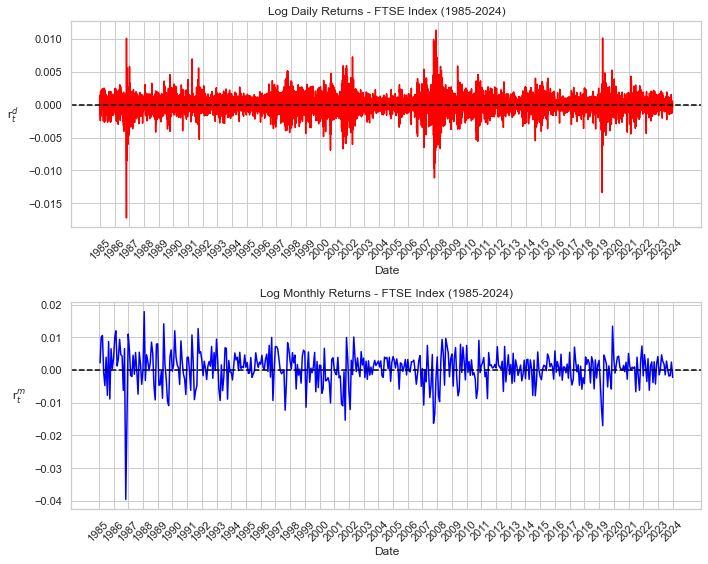

In [984]:
# Creation of a figure with 2 subplots (daily and monthly only)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Daily Log Returns 
axs[0].plot(rt_d_all.index, rt_d_all, color='red')
axs[0].axhline(y=0, color='black', linestyle='--')
axs[0].set_title('Log Daily Returns - FTSE Index (1985-2024)')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('r$_t^d$', rotation=0, labelpad=15)
axs[0].grid(True)

# We add the year for plot 1
date_labels = pd.date_range(start='1985-12-31', end='2024-12-31', freq='A-DEC')
formatted_labels = [f'{date.year}' for date in date_labels]
axs[0].set_xticks(date_labels)
axs[0].set_xticklabels(formatted_labels, rotation=45)

# Plot 2: Monthly Log Returns 
axs[1].plot(rt_m_all.index, rt_m_all, color='blue')
axs[1].axhline(y=0, color='black', linestyle='--')
axs[1].set_title('Log Monthly Returns - FTSE Index (1985-2024)')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('r$_t^m$', rotation=0, labelpad=15)
axs[1].grid(True)

# We add the year for plot 2
axs[1].set_xticks(date_labels)
axs[1].set_xticklabels(formatted_labels, rotation=45)

# Adjusted spacing between plots
plt.tight_layout()

# Display 
plt.show()


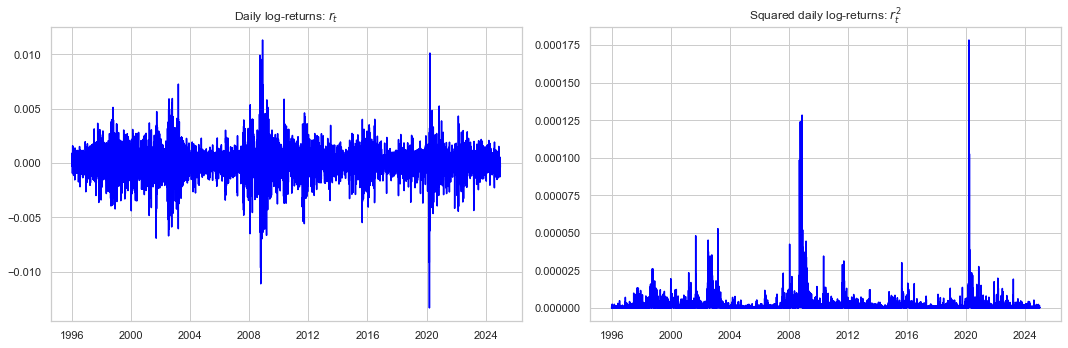

In [985]:
# Definition of the date interval (subsample from 1996 onwards)
ss_start_date = pd.to_datetime('1995-12-31')
ss_end_date = pd.to_datetime('2024-12-31')

# Selecting the interval using .loc (only for pandas series)
pt_d_sub = pt_d_all.loc[ss_start_date:ss_end_date]
pt_w_sub = pt_w_all.loc[ss_start_date:ss_end_date]
pt_m_sub = pt_m_all.loc[ss_start_date:ss_end_date]
pt_y_sub = pt_y_all.loc[ss_start_date:ss_end_date]

rt_d_sub = rt_d_all.loc[ss_start_date:ss_end_date]
rt_w_sub = rt_w_all.loc[ss_start_date:ss_end_date]
rt_m_sub = rt_m_all.loc[ss_start_date:ss_end_date]
rt_y_sub = rt_y_all.loc[ss_start_date:ss_end_date]

# Setting the 1x2 windows layout
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Daily log-returns 
axs[0].plot(rt_d_sub.index, rt_d_sub, color='blue')
axs[0].set_title('Daily log-returns: $r_t$')
axs[0].grid(True)

# Plot 2: Squared daily log-returns 
axs[1].plot(rt_d_sub.index, rt_d_sub**2, color='blue')
axs[1].set_title('Squared daily log-returns: $r_t^2$')
axs[1].grid(True)

# Formatting margins and plot
plt.tight_layout()
plt.show()


Log price for comaprison:

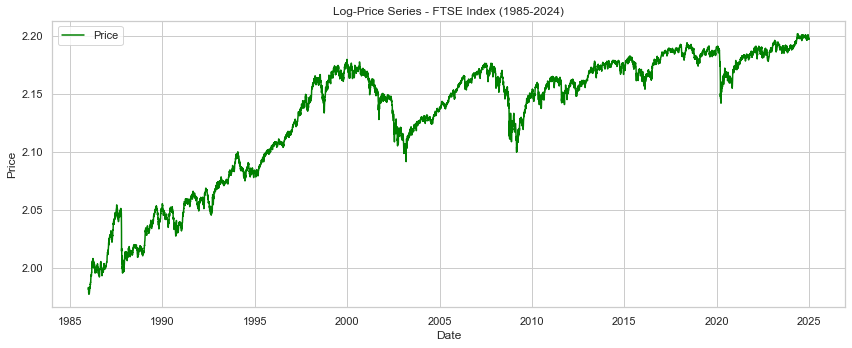

In [986]:
# Log Price Series for Comparison
plt.figure(figsize=(12, 5))
plt.plot(pt_d_all.index, np.log(pt_d_all), label='Price', color='green')
plt.title("Log-Price Series - FTSE Index (1985-2024)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Augmented Dickey-Fuller (ADF) Test:

In [987]:

# ADF Test on price series:
adf_price = adfuller(pt_d_all)
print('ADF Statistic for Price:', adf_price[0])
print('p-value:', adf_price[1])

# ADF Test on returns series:
adf_returns = adfuller(rt_d_all) 
print('ADF Statistic for Returns:', adf_returns[0])
print('p-value:', adf_returns[1])


ADF Statistic for Price: -2.2786775487891138
p-value: 0.17893712344684465
ADF Statistic for Returns: -18.623778676788227
p-value: 2.0602360470859577e-30


Save as CSV:

In [988]:
rt_d_all.to_csv("pt_d_all.csv")
pt_d_all.to_csv("rt_d_all.csv")  

### Stylized Fact 3

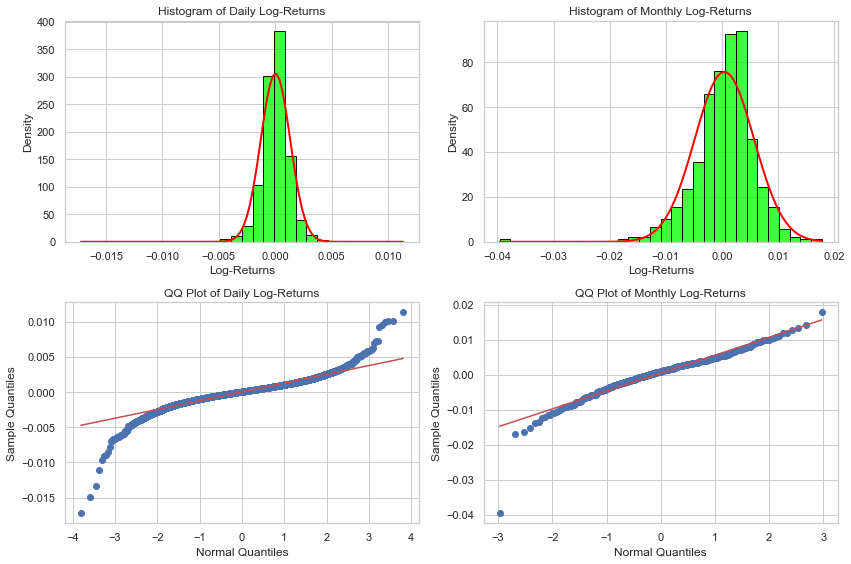

In [989]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Histogram of daily log-returns 
sb.histplot(rt_d_all, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 0], stat='density')
axs[0, 0].plot(np.linspace(rt_d_all.min(), rt_d_all.max(), 100),
               stats.norm.pdf(np.linspace(rt_d_all.min(), rt_d_all.max(), 100),
                              rt_d_all.mean(), rt_d_all.std()), color='red', linewidth=2)
axs[0, 0].set_title('Histogram of Daily Log-Returns')
axs[0, 0].set_xlabel('Log-Returns')
axs[0, 0].set_ylabel('Density')

# Histogram of monthly log-returns 
sb.histplot(rt_m_all, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 1], stat='density')
axs[0, 1].plot(np.linspace(rt_m_all.min(), rt_m_all.max(), 100),
               stats.norm.pdf(np.linspace(rt_m_all.min(), rt_m_all.max(), 100),
                              rt_m_all.mean(), rt_m_all.std()), color='red', linewidth=2)
axs[0, 1].set_title('Histogram of Monthly Log-Returns')
axs[0, 1].set_xlabel('Log-Returns')
axs[0, 1].set_ylabel('Density')

# QQ plot of daily log-returns 
qqplotaxes = stats.probplot(rt_d_all, dist='norm', plot=axs[1, 0])
axs[1, 0].set_title('QQ Plot of Daily Log-Returns')
axs[1, 0].set_xlabel('Normal Quantiles')
axs[1, 0].set_ylabel('Sample Quantiles')

# QQ plot of monthly log-returns 
qqplotaxes = stats.probplot(rt_m_all, dist='norm', plot=axs[1, 1])
axs[1, 1].set_title('QQ Plot of Monthly Log-Returns')
axs[1, 1].set_xlabel('Normal Quantiles')
axs[1, 1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('hist_qqplot_FTSE.png', format='png', bbox_inches='tight')
plt.show()


Zoomed in and detailed histogram of daily log returns

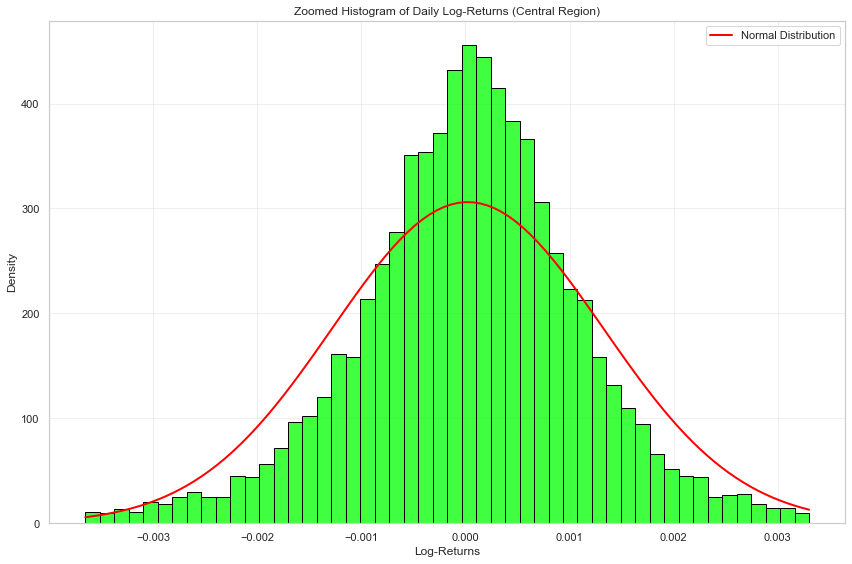

In [990]:
#Creation of zoomed in histogram for daily log-returns
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

#Definition of range: we focus on 98% of  the data by removing 1% on the left and right
lower_percentile = 1  
upper_percentile = 99 

#Zoom range
zoom_min = np.percentile(rt_d_all, lower_percentile)
zoom_max = np.percentile(rt_d_all, upper_percentile)

# Filtering the data to the zoom range
rt_d_zoomed = rt_d_all[(rt_d_all >= zoom_min) & (rt_d_all <= zoom_max)]

# Creation of the histogram with more intervals for better detail
sb.histplot(rt_d_zoomed, bins=50, color='lime', edgecolor='black', 
            kde_kws={'color': 'red'}, ax=ax, stat='density')

# Overlay the normal distribution for comparison
ax.plot(np.linspace(zoom_min, zoom_max, 100),
        stats.norm.pdf(np.linspace(zoom_min, zoom_max, 100),
                      rt_d_all.mean(), rt_d_all.std()), 
        color='red', linewidth=2, label='Normal Distribution')

ax.set_title('Zoomed Histogram of Daily Log-Returns (Central Region)')
ax.set_xlabel('Log-Returns')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hist_qqplot_FTSE_zoomed.png', format='png', bbox_inches='tight')
plt.show()


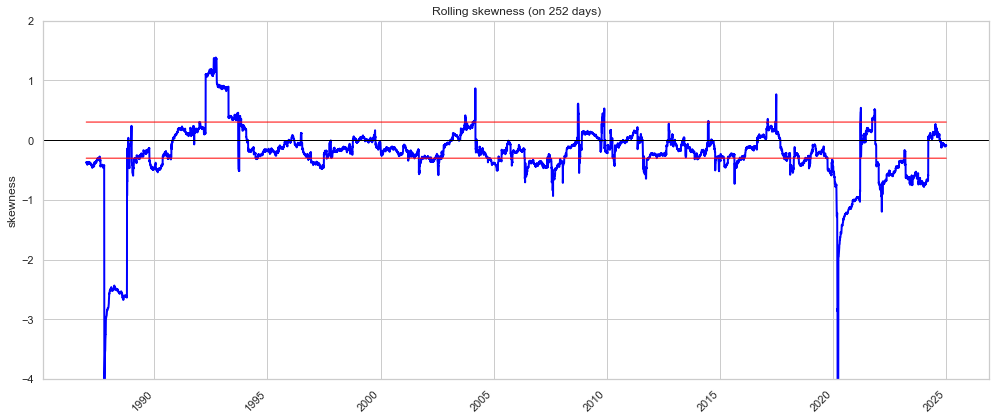

In [991]:
# Calculation of the rolling skewness (252 trading days = 1 year)

window_length = 252
roll_mom_manual = rt_d_all.rolling(window=window_length)

# Skewness extraction (3rd moment)
skew_plot = roll_mom_manual.skew()

# Calculation of the upper and lower confidence bounds for skewness
# Standard error formula: sqrt(6/n)
skew_plot_ub = np.full(skew_plot.shape[0], +1.96*np.sqrt(6)/np.sqrt(window_length))
skew_plot_lb = np.full(skew_plot.shape[0], -1.96*np.sqrt(6)/np.sqrt(window_length))

# Creation of DataFrame with the index
data_index = rt_d_all.index
data2plot_na = pd.DataFrame({'Skewness': skew_plot, 
                              'LowerBound': skew_plot_lb, 
                              'UpperBound': skew_plot_ub}, 
                              index=data_index)

# Remove missing values
data2plot = data2plot_na.dropna()

# Plot creation
plt.figure(figsize=(14, 6))
plt.plot(data2plot.index, data2plot["Skewness"], color='blue', linestyle='-', linewidth=2)
plt.plot(data2plot.index, data2plot["LowerBound"], color='red', linestyle='-', linewidth=1)
plt.plot(data2plot.index, data2plot["UpperBound"], color='red', linestyle='-', linewidth=1)
plt.ylim(-4, 2)
plt.grid(True)
plt.xlabel('')
plt.ylabel('skewness')
plt.title('Rolling skewness (on 252 days)')
plt.axhline(0, linestyle='-', color='black', linewidth=1)

# Auto formatting the x-axis dates
plt.gcf().autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


### Stylized Fact 4

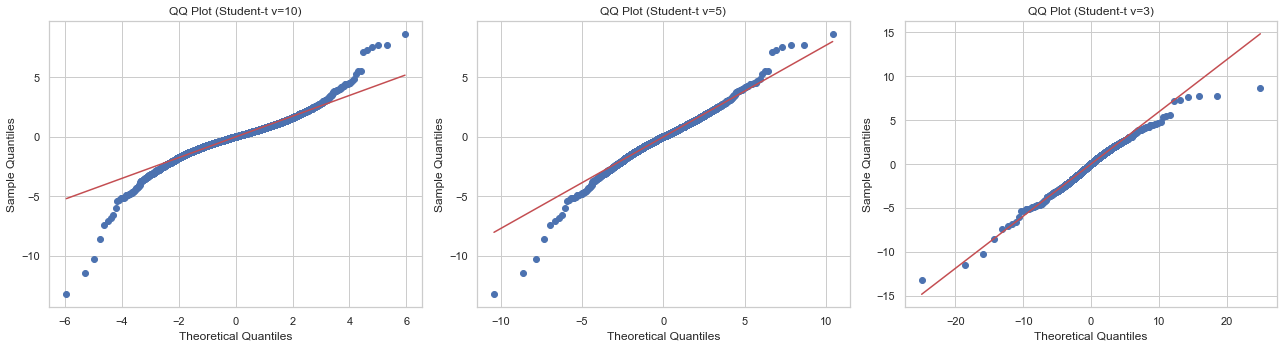

In [992]:
# Standardization of our returns: zero mean, unit variance
#We standardize once so we don't need to do it over and over each time 
rt_d_all_std = (rt_d_all - rt_d_all.mean()) / rt_d_all.std()

# Creation of the three QQ plots for different degrees of freedom
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# QQ plot against Student-t distribution with ν = 10
stats.probplot(rt_d_all_std, dist=stats.t(df=10), plot=axs[0])
axs[0].set_title('QQ Plot (Student-t ν=10)')
axs[0].set_xlabel('Theoretical Quantiles')
axs[0].set_ylabel('Sample Quantiles')

# QQ plot against Student-t distribution with ν = 5
stats.probplot(rt_d_all_std, dist=stats.t(df=5), plot=axs[1])
axs[1].set_title('QQ Plot (Student-t ν=5)')
axs[1].set_xlabel('Theoretical Quantiles')
axs[1].set_ylabel('Sample Quantiles')

# QQ plot against Student-t distribution with ν = 3
stats.probplot(rt_d_all_std, dist=stats.t(df=3), plot=axs[2])
axs[2].set_title('QQ Plot (Student-t ν=3)')
axs[2].set_xlabel('Theoretical Quantiles')
axs[2].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


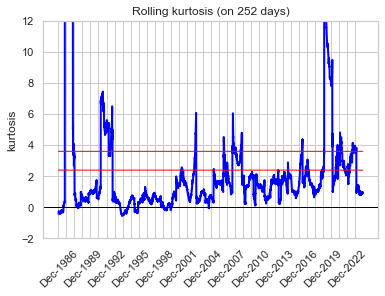

In [993]:
# Rolling window length for 252 trading days (~1 year)
window_length = 252

# Calculation of the rolling kurtosis
kurt_plot = rt_d_all.rolling(window=window_length).kurt()

# Upper and lower bounds for sample kurtosis (normal distribution, finite sample)
kurt_plot_ub = np.full(kurt_plot.shape[0], 3 + 1.96 * np.sqrt(24) / np.sqrt(window_length))
kurt_plot_lb = np.full(kurt_plot.shape[0], 3 - 1.96 * np.sqrt(24) / np.sqrt(window_length))

# Preparation of the data frame
data2plot_na = pd.DataFrame({
    'Kurtosis': kurt_plot,
    'LowerBound': kurt_plot_lb,
    'UpperBound': kurt_plot_ub
}, index=rt_d_all.index)

# We drop missing values (we only keep complete windows)
data2plot = data2plot_na.dropna()
data2plot

# Custom x-axis ticks: December 31 year end, show every 3 years
date_labels = pd.date_range(start=data2plot.index[0], end=data2plot.index[-1], freq='A-DEC')  
formatted_labels = [f'Dec-{date.year}' if date.year % 3 == 0 else '' for date in date_labels]
plt.xticks(date_labels, formatted_labels, rotation=45)


# Plot of the rolling kurtosis 
plt.plot(data2plot.index, data2plot['Kurtosis'], color='blue', linestyle='-', linewidth=2)
plt.plot(data2plot.index, data2plot['LowerBound'], color='red', linestyle='-', linewidth=1)
plt.plot(data2plot.index, data2plot['UpperBound'], color='red', linestyle='-', linewidth=1)
plt.ylim(-2, 12)
plt.grid(True)
plt.xlabel('')
plt.ylabel('kurtosis')
plt.title('Rolling kurtosis (on 252 days)')
plt.axhline(0, linestyle='-', color='black', linewidth=1)

plt.savefig('SP500_kurt_rolling_1981_2018.png', format='png', bbox_inches='tight')
plt.show()


### Stylized Fact 5

Histogram and Normal Distribution Comparison

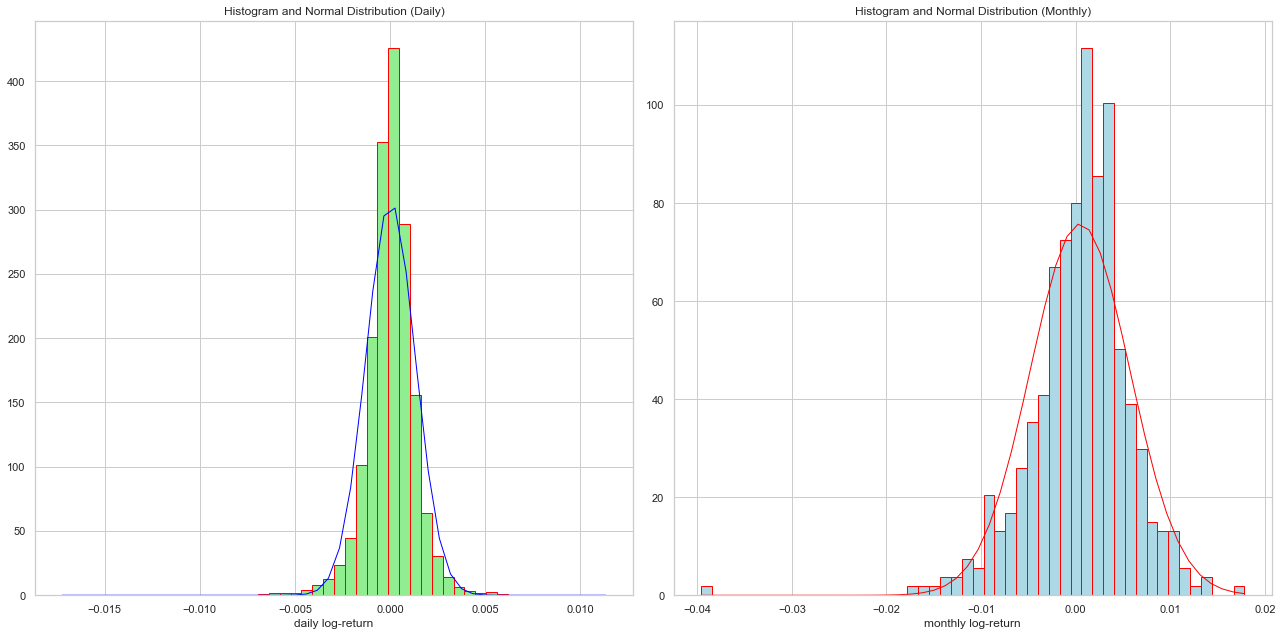

In [994]:
# We set up the subplots
fig, axs = plt.subplots(1, 2, figsize=(18, 9))

# Histogram and Normal Distribution (Daily)
axs[0].hist(rt_d_all, bins=50, density=True, color='lightgreen', edgecolor='red')
norm_y = stats.norm.pdf(np.linspace(rt_d_all.min(), rt_d_all.max()), 
                         loc=np.mean(rt_d_all), scale=np.std(rt_d_all))
axs[0].plot(np.linspace(rt_d_all.min(), rt_d_all.max()), norm_y, 
            color="blue", linewidth=1)
axs[0].set_xlabel("daily log-return")
axs[0].set_title("Histogram and Normal Distribution (Daily)")

# Histogram and Normal Distribution (Monthly)
axs[1].hist(rt_m_all, bins=50, density=True, color='lightblue', edgecolor='red')
norm_y = stats.norm.pdf(np.linspace(rt_m_all.min(), rt_m_all.max()), 
                         loc=np.mean(rt_m_all), scale=np.std(rt_m_all))
axs[1].plot(np.linspace(rt_m_all.min(), rt_m_all.max()), norm_y, 
            color="red", linewidth=1)
axs[1].set_xlabel("monthly log-return")
axs[1].set_title("Histogram and Normal Distribution (Monthly)")

# Adjusted layout and plot display
plt.tight_layout()
plt.show()


Probability Plot (QQ-Plot) for Daily and Monthly



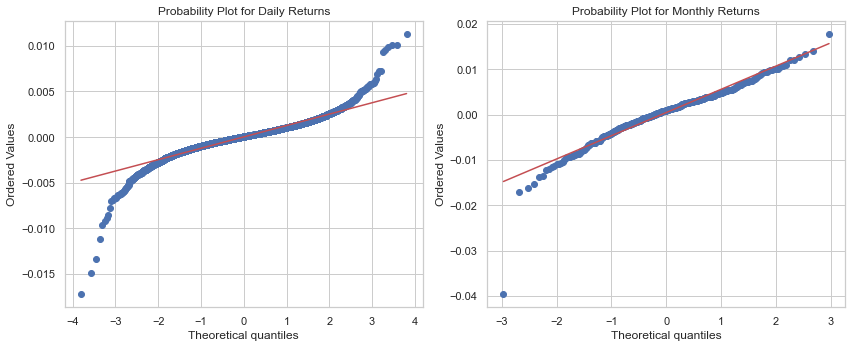

In [995]:
# Subplot set up
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Probability Plot for Daily Returns 
stats.probplot(rt_d_all, dist="norm", plot=axs[0])
axs[0].set_title("Probability Plot for Daily Returns")

# Probability Plot for Monthly Returns 
stats.probplot(rt_m_all, dist="norm", plot=axs[1])
axs[1].set_title("Probability Plot for Monthly Returns")

# Adjusted layout and plot display
plt.tight_layout()
plt.show()


We now check how QQ-Plots change with aggregation (with all 4 frequencies)

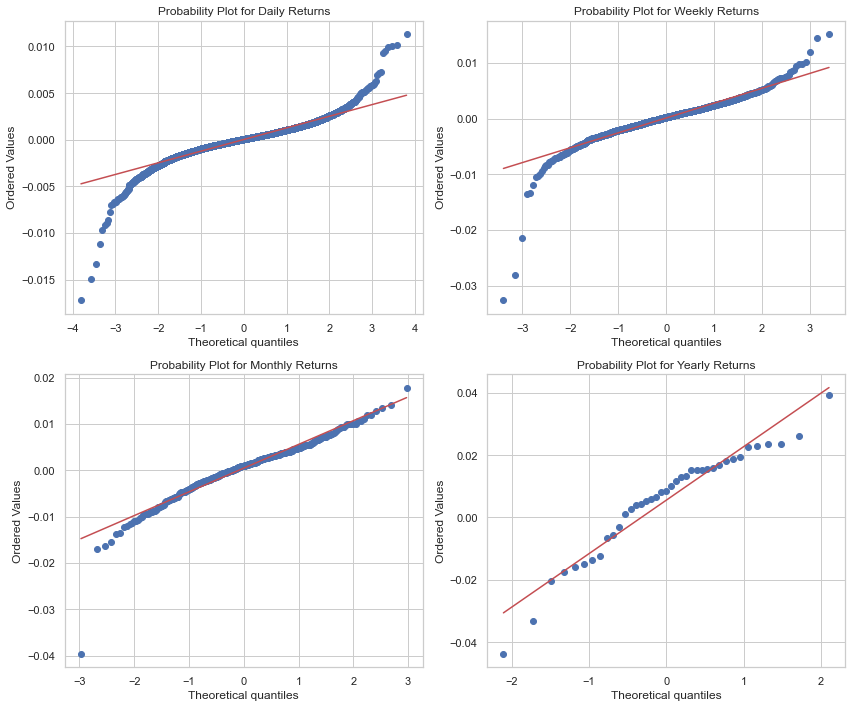

In [996]:
# Subplot set up
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Probability Plot for Daily Returns
stats.probplot(rt_d_all, dist="norm", plot=axs[0, 0])
axs[0, 0].set_title("Probability Plot for Daily Returns")
axs[0, 0].grid(True)

# Probability Plot for Weekly Returns 
stats.probplot(rt_w_all, dist="norm", plot=axs[0, 1])
axs[0, 1].set_title("Probability Plot for Weekly Returns")
axs[0, 1].grid(True)

# Probability Plot for Monthly Returns 
stats.probplot(rt_m_all, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title("Probability Plot for Monthly Returns")
axs[1, 0].grid(True)

# Probability Plot for Yearly Returns 
stats.probplot(rt_y_all, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title("Probability Plot for Yearly Returns")
axs[1, 1].grid(True)

# Adjusted layout and plot display
plt.tight_layout()
plt.show()


Jarque-Bera Test (Aggregational Normality)

In [997]:
print("JB p-value", "daily", "returns:", jarque_bera(rt_d_all)[1])
print("JB p-value", "weekly", "returns:", jarque_bera(rt_w_all)[1])
print("JB p-value", "monthly", "returns:", jarque_bera(rt_m_all)[1])
print("JB p-value", "yearly", "returns:", jarque_bera(rt_y_all)[1])

JB p-value daily returns: 0.0
JB p-value weekly returns: 0.0
JB p-value monthly returns: 1.1528680607991255e-242
JB p-value yearly returns: 0.0760116967811795


Jarque-Bera Test Statistics (Daily Returns)

In [998]:
# We compute JB test for daily returns
JB_rt_d = jarque_bera(rt_d_all)
# first position (0): statistic
print("JB Stat: ", round(JB_rt_d[0], 3))
# second position (1): p-value
print("JB p-value: ", JB_rt_d[1])


JB Stat:  59794.46
JB p-value:  0.0


Manual JB Test (with yearly returns)

In [999]:
a = jarque_bera(rt_y_all)
x = rt_y_all
n = len(x)                          # Number of observations
m1 = sum(x)/n                       # Mean
m2 = sum((x-m1)**2)/n               # Used in denominator of both
m3 = sum((x-m1)**3)/n               # For numerator of S
m4 = sum((x-m1)**4)/n               # For numerator of K
b1 = (m3/m2**(3/2))**2              # S
b2 = (m4/m2**2)                     # K
STATISTIC = n*b1/6+n*(b2-3)**2/24

print("Manually:", STATISTIC)
print("and using the function:", a[0])


Manually: 5.153736091044892
and using the function: 5.153736091044897


Lilliefors Test (Yearly Returns)



In [1000]:
lill_rt_y = kstest(rt_y_all, 'norm', args=(np.mean(rt_y_all), np.std(rt_y_all)))
print("Stat:", lill_rt_y[0])
print("p-val:", lill_rt_y[1])


Stat: 0.13403900407439323
p-val: 0.44652736613173594


Kolmogorov-Smirnov Test (Yearly Returns)

In [1001]:
ks_rt_y = kstest(rt_y_all, 'norm')
print("Stat:", ks_rt_y[0])
print("p-val:", ks_rt_y[1])


Stat: 0.4842923090214213
p-val: 6.048477062603752e-09


### Stylized Fact 6

ACF Plots for Returns (d, w, m)

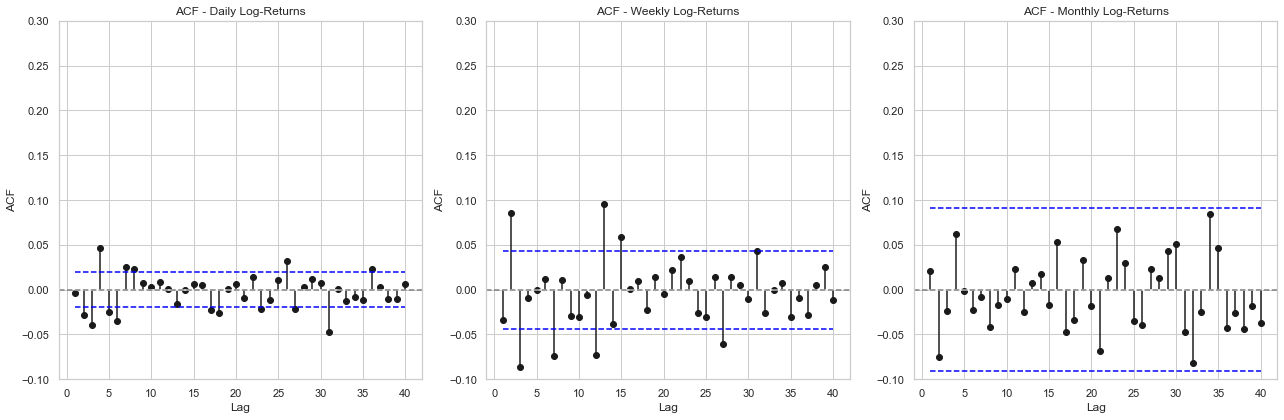

In [1002]:
# Lay out set up
lags = 40
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# ACF of Daily Log-Returns 
acf_values_daily = acf(rt_d_all, nlags=lags)

# Computation of the Bartlet intervals
confint = 1.96 / np.sqrt(len(rt_d_all))
confint_upper = np.full(lags, confint)
confint_lower = -np.full(lags, confint)

axs[0].stem(np.arange(1, lags + 1), acf_values_daily[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].plot(np.arange(1, lags + 1), confint_upper, color='blue', linestyle='dashed')
axs[0].plot(np.arange(1, lags + 1), confint_lower, color='blue', linestyle='dashed')
axs[0].set_ylim(-0.1, 0.3)
axs[0].set_title('ACF - Daily Log-Returns')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('ACF')
axs[0].grid(True)

# ACF of Weekly Log-Returns 
acf_values_weekly = acf(rt_w_all, nlags=lags)
confint_weekly = 1.96 / np.sqrt(len(rt_w_all))
confint_weekly_upper = np.full(lags, confint_weekly)
confint_weekly_lower = -np.full(lags, confint_weekly)

axs[1].stem(np.arange(1, lags + 1), acf_values_weekly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_upper, color='blue', linestyle='dashed')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_lower, color='blue', linestyle='dashed')
axs[1].set_ylim(-0.1, 0.3)
axs[1].set_title('ACF - Weekly Log-Returns')
axs[1].set_xlabel('Lag')
axs[1].set_ylabel('ACF')
axs[1].grid(True)

# ACF of Monthly Log-Returns 
acf_values_monthly = acf(rt_m_all, nlags=lags)
confint_monthly = 1.96 / np.sqrt(len(rt_m_all))
confint_monthly_upper = np.full(lags, confint_monthly)
confint_monthly_lower = -np.full(lags, confint_monthly)

axs[2].stem(np.arange(1, lags + 1), acf_values_monthly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[2].axhline(y=0, color='gray', linestyle='--')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_upper, color='blue', linestyle='dashed')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_lower, color='blue', linestyle='dashed')
axs[2].set_ylim(-0.1, 0.3)
axs[2].set_title('ACF - Monthly Log-Returns')
axs[2].set_xlabel('Lag')
axs[2].set_ylabel('ACF')
axs[2].grid(True)

# Formating
plt.tight_layout()
plt.show()


Confidence Intervals

In [1003]:
print("Daily:", "+/-", round(1.96/np.sqrt(len(rt_d_all)), 3))
print("Weekly:", "+/-", round(1.96/np.sqrt(len(rt_w_all)), 3))
print("Monthly:", "+/-", round(1.96/np.sqrt(len(rt_m_all)), 3))


Daily: +/- 0.02
Weekly: +/- 0.043
Monthly: +/- 0.091


Box-Pierce and Ljung-Box Tests (with lag = 1)

In [1004]:
# Box-Pierce and Ljung-Box tests: lag = 1
lbbp_test_rt_d = sm.stats.acorr_ljungbox(rt_d_all, lags=[1], boxpierce=True)
bp_stat = lbbp_test_rt_d['bp_stat'].iloc[0]
lb_stat = lbbp_test_rt_d['lb_stat'].iloc[0]
bp_pval = lbbp_test_rt_d['bp_pvalue'].iloc[0]
lb_pval = lbbp_test_rt_d['lb_pvalue'].iloc[0]

print("Box-Pierce, lag=1:", "Stat:", round(bp_stat, 3), "- p-value:", round(bp_pval, 3))
print("Ljung-Box, lag=1:", "Stat:", round(lb_stat, 3), "- p-value:", round(lb_pval, 3))

Box-Pierce, lag=1: Stat: 0.123 - p-value: 0.726
Ljung-Box, lag=1: Stat: 0.123 - p-value: 0.726


Box-Pierce and Ljung-Box Tests (lag = 1 to 5)

In [1005]:
# Ljung-Box test with lag from 1 to 5
lbbp_test_rt_d_5 = sm.stats.acorr_ljungbox(rt_d_all, lags=[1, 2, 3, 4, 5], boxpierce=True)
bp_stat5 = lbbp_test_rt_d_5['bp_stat'].iloc[0]
lb_stat5 = lbbp_test_rt_d_5['lb_stat'].iloc[0]
bp_pval5 = lbbp_test_rt_d_5['bp_pvalue'].iloc[0]
lb_pval5 = lbbp_test_rt_d_5['lb_pvalue'].iloc[0]

print("Box-Pierce, lag=5:", "Stat:", round(bp_stat5, 3), "- p-value:", round(bp_pval5, 3))
print("Ljung-Box, lag=5:", "Stat:", round(lb_stat5, 3), "- p-value:", round(lb_pval5, 3))


Box-Pierce, lag=5: Stat: 0.123 - p-value: 0.726
Ljung-Box, lag=5: Stat: 0.123 - p-value: 0.726


Detailed ACF Table with Box-Pierce and Ljung-Box Tests

In [1006]:
# Maximum lag def
my_max_lag = 25
lags_all = np.arange(1, my_max_lag + 1)

# Empirical ACF computation
my_acf = sm.tsa.acf(rt_d_all, nlags=my_max_lag)

# ACF diameter (confidence interval)
my_acf_diameter = 1.96 / np.sqrt(len(rt_d_all))

# ACF t-test statistic
my_acf_tstat_0 = (my_acf[1:] - 0) / np.sqrt(1 / len(rt_d_all))

# Ljung-Box test
my_LjungBox = sm.stats.diagnostic.acorr_ljungbox(rt_d_all, lags=lags_all, boxpierce=False)

# Box-Pierce test
my_BoxPierce = sm.stats.diagnostic.acorr_ljungbox(rt_d_all, lags=lags_all, boxpierce=True)

# Chi-square critical value
crit_value_5_BP = stats.chi2.ppf(0.95, lags_all)

# Table
my_table = np.column_stack((
    lags_all,
    my_acf[1:],
    np.full(my_max_lag, my_acf_diameter),
    my_acf_tstat_0,
    my_BoxPierce['bp_stat'],
    my_BoxPierce['bp_pvalue'],
    my_LjungBox['lb_stat'],
    my_LjungBox['lb_pvalue'],
    np.full(my_max_lag, crit_value_5_BP)
))

column_names = ["lag", "acf", "acf diam.", "acf test", 
                "B-P stat", "B-P pval", "L-B stat", "L-B pval", "crit"]
my_table_df = pd.DataFrame(data=my_table, columns=column_names)


my_table_df = my_table_df.round(3)
print(my_table_df)


        lag      acf  acf diam.  acf test  B-P stat  B-P pval  L-B stat  \
0   1.00000 -0.00400    0.02000  -0.35100   0.12300   0.72600   0.12300   
1   2.00000 -0.02800    0.02000  -2.77200   7.80800   0.02000   7.81200   
2   3.00000 -0.03900    0.02000  -3.86700  22.76400   0.00000  22.77400   
3   4.00000  0.04700    0.02000   4.65900  44.46700   0.00000  44.49100   
4   5.00000 -0.02400    0.02000  -2.42900  50.36800   0.00000  50.39700   
5   6.00000 -0.03500    0.02000  -3.51200  62.70100   0.00000  62.74000   
6   7.00000  0.02500    0.02000   2.51800  69.04200   0.00000  69.08600   
7   8.00000  0.02300    0.02000   2.24500  74.08000   0.00000  74.12900   
8   9.00000  0.00800    0.02000   0.76200  74.66100   0.00000  74.71000   
9  10.00000  0.00300    0.02000   0.26900  74.73300   0.00000  74.78300   
10 11.00000  0.00900    0.02000   0.85700  75.46800   0.00000  75.51800   
11 12.00000  0.00100    0.02000   0.05000  75.47000   0.00000  75.52100   
12 13.00000 -0.01500    0

Test on Monthly Returns

In [1007]:
# Box-Pierce and Ljung-Box tests on monthly returns
lbbp_test_rt_m = sm.stats.acorr_ljungbox(rt_m_all, lags=[1], boxpierce=True)
bp_stat_m = lbbp_test_rt_m['bp_stat'].iloc[0]
lb_stat_m = lbbp_test_rt_m['lb_stat'].iloc[0]
bp_pval_m = lbbp_test_rt_m['bp_pvalue'].iloc[0]
lb_pval_m = lbbp_test_rt_m['lb_pvalue'].iloc[0]

print("MONTHLY RETURNS:")
print("Box-Pierce, lag=1:", "Stat:", round(bp_stat_m, 3), "- p-value:", round(bp_pval_m, 3))
print("Ljung-Box, lag=1:", "Stat:", round(lb_stat_m, 3), "- p-value:", round(lb_pval_m, 3))


MONTHLY RETURNS:
Box-Pierce, lag=1: Stat: 0.198 - p-value: 0.657
Ljung-Box, lag=1: Stat: 0.199 - p-value: 0.656


Daily returns: Ljung-Box & Box-Pierce Tests

In [1008]:
#Error fix:
ss_start_date3 = pd.to_datetime('1985-12-01')
ss_end_date3 = pd.to_datetime('2024-12-31')

rt_d = rt_d_all.loc[ss_start_date3:ss_end_date3]


In [1009]:
# Test statistics and p-values and assignement to variables
lbp_test = sm.stats.acorr_ljungbox(rt_d, lags=[1], boxpierce=True)
bp_stat = lbp_test['bp_stat'].iloc[0]
lb_stat = lbp_test['lb_stat'].iloc[0]
bp_pval = lbp_test['bp_pvalue'].iloc[0]
lb_pval = lbp_test['lb_pvalue'].iloc[0]

# Assignement of variables for the lags, the ACF, its diameter and test statistics
# Ljung-Box and Box-Pierce test statistics and critical values
max_lag = 26
lags_all = np.arange(1, max_lag + 1)
acf_value = sm.tsa.acf(rt_d, nlags=max_lag, fft=False)
acf_diameter = 1.96 / np.sqrt(len(rt_d))
acf_tstat_0 = (acf_value[1:] - 0) / np.sqrt(1 / len(rt_d))
LjungBox = sm.stats.diagnostic.acorr_ljungbox(rt_d, lags=lags_all)
BoxPierce = sm.stats.diagnostic.acorr_ljungbox(rt_d, lags=lags_all, boxpierce=True)
crit_value_5_BP = stats.chi2.ppf(0.95, lags_all)

# Table with all the data 
stats_table = np.column_stack((
    lags_all,
    acf_value[1:],
    np.full(max_lag, acf_diameter),
    acf_tstat_0,
    BoxPierce['bp_stat'],
    BoxPierce['bp_pvalue'],
    LjungBox['lb_stat'],
    LjungBox['lb_pvalue'],
    np.full(max_lag, crit_value_5_BP)
))

column_names = ["Lag", "ACF", "ACF Diameter", "ACF Test", "Box-Pierce Stat", 
                "Box-Pierce P-value", "Ljung-Box Stat", "Ljung-Box P-value", 
                "Critical Value (5%)"]
stats_table_df = pd.DataFrame(data=stats_table, columns=column_names)

stats_table_df = stats_table_df.round(3)
stats_table_df


,Lag,ACF,ACF Diameter,ACF Test,Box-Pierce Stat,Box-Pierce P-value,Ljung-Box Stat,Ljung-Box P-value,Critical Value (5%)
0,1.00000,-0.00400,0.02000,-0.35100,0.12300,0.72600,0.12300,0.72600,3.84100
1,2.00000,-0.02800,0.02000,-2.77200,7.80800,0.02000,7.81200,0.02000,5.99100
2,3.00000,-0.03900,0.02000,-3.86700,22.76400,0.00000,22.77400,0.00000,7.81500
3,4.00000,0.04700,0.02000,4.65900,44.46700,0.00000,44.49100,0.00000,9.48800
4,5.00000,-0.02400,0.02000,-2.42900,50.36800,0.00000,50.39700,0.00000,11.07000
5,6.00000,-0.03500,0.02000,-3.51200,62.70100,0.00000,62.74000,0.00000,12.59200
6,7.00000,0.02500,0.02000,2.51800,69.04200,0.00000,69.08600,0.00000,14.06700
7,8.00000,0.02300,0.02000,2.24500,74.08000,0.00000,74.12900,0.00000,15.50700
8,9.00000,0.00800,0.02000,0.76200,74.66100,0.00000,74.71000,0.00000,16.91900
9,10.00000,0.00300,0.02000,0.26900,74.73300,0.00000,74.78300,0.00000,18.30700


Weekly returns: Ljung-Box & Box-Pierce Tests

In [1010]:
# Calculation of weekly log returns from our daily log returns
rt_w = rt_d_all.resample('W').sum()  

max_lag = 26
lags_all = np.arange(1, max_lag + 1)
acf_value = sm.tsa.acf(rt_w, nlags=max_lag, fft=False)
acf_diameter = 1.96 / np.sqrt(len(rt_w))
acf_tstat_0 = (acf_value[1:] - 0) / np.sqrt(1 / len(rt_w))
LjungBox = sm.stats.diagnostic.acorr_ljungbox(rt_w, lags=lags_all)
BoxPierce = sm.stats.diagnostic.acorr_ljungbox(rt_w, lags=lags_all, boxpierce=True)
crit_value_5_BP = stats.chi2.ppf(0.95, lags_all)

# Table with all the data 
stats_table = np.column_stack((
    lags_all,
    acf_value[1:],
    np.full(max_lag, acf_diameter),
    acf_tstat_0,
    BoxPierce['bp_stat'],
    BoxPierce['bp_pvalue'],
    LjungBox['lb_stat'],
    LjungBox['lb_pvalue'],
    np.full(max_lag, crit_value_5_BP)
))

column_names = ["Lag", "ACF", "ACF Diameter", "ACF Test", "Box-Pierce Stat", 
                "Box-Pierce P-value", "Ljung-Box Stat", "Ljung-Box P-value", 
                "Critical Value (5%)"]
stats_table_df = pd.DataFrame(data=stats_table, columns=column_names)

stats_table_df = stats_table_df.round(3)
stats_table_df


,Lag,ACF,ACF Diameter,ACF Test,Box-Pierce Stat,Box-Pierce P-value,Ljung-Box Stat,Ljung-Box P-value,Critical Value (5%)
0,1.00000,-0.03400,0.04300,-1.55600,2.42200,0.12000,2.42600,0.11900,3.84100
1,2.00000,0.08500,0.04300,3.84300,17.19300,0.00000,17.22600,0.00000,5.99100
2,3.00000,-0.08700,0.04300,-3.90800,32.46800,0.00000,32.53800,0.00000,7.81500
3,4.00000,-0.00900,0.04300,-0.39200,32.62100,0.00000,32.69200,0.00000,9.48800
4,5.00000,-0.00000,0.04300,-0.00400,32.62100,0.00000,32.69200,0.00000,11.07000
5,6.00000,0.01200,0.04300,0.53400,32.90700,0.00000,32.97900,0.00000,12.59200
6,7.00000,-0.07400,0.04300,-3.32900,43.98900,0.00000,44.11000,0.00000,14.06700
7,8.00000,0.01100,0.04300,0.50000,44.23900,0.00000,44.36100,0.00000,15.50700
8,9.00000,-0.02900,0.04300,-1.31800,45.97600,0.00000,46.10800,0.00000,16.91900
9,10.00000,-0.03000,0.04300,-1.36100,47.82800,0.00000,47.97100,0.00000,18.30700


Monthly returns: Ljung-Box & Box-Pierce Tests



In [1011]:
# Daily log returns 
rt_d_all = np.log(Pt_d_all / Pt_d_all.shift(1)).dropna()

# Monthly log returns (rt_m)
# Sum of daily log returns within each month (approximate compounded return)
rt_m = rt_d_all.resample('M').sum()  

# Test statistics and p-values and assignement to variables
lbp_test = sm.stats.acorr_ljungbox(rt_m, lags=[1], boxpierce=True)
bp_stat = lbp_test['bp_stat'].iloc[0]
lb_stat = lbp_test['lb_stat'].iloc[0]
bp_pval = lbp_test['bp_pvalue'].iloc[0]
lb_pval = lbp_test['lb_pvalue'].iloc[0]

# Ljung-Box and Box-Pierce test statistics and critical values.
max_lag = 26
lags_all = np.arange(1, max_lag + 1)
acf_value = sm.tsa.acf(rt_m, nlags=max_lag, fft=False)
acf_diameter = 1.96 / np.sqrt(len(rt_m))
acf_tstat_0 = (acf_value[1:] - 0) / np.sqrt(1 / len(rt_m))
LjungBox = sm.stats.diagnostic.acorr_ljungbox(rt_m, lags=lags_all)
BoxPierce = sm.stats.diagnostic.acorr_ljungbox(rt_m, lags=lags_all, boxpierce=True)
crit_value_5_BP = stats.chi2.ppf(0.95, lags_all)

# Table w/ all the data
stats_table = np.column_stack((
    lags_all,
    acf_value[1:],
    np.full(max_lag, acf_diameter),
    acf_tstat_0,
    BoxPierce['bp_stat'],
    BoxPierce['bp_pvalue'],
    LjungBox['lb_stat'],
    LjungBox['lb_pvalue'],
    np.full(max_lag, crit_value_5_BP)
))

column_names = ["Lag", "ACF", "ACF Diameter", "ACF Test", "Box-Pierce Stat", 
                "Box-Pierce P-value", "Ljung-Box Stat", "Ljung-Box P-value", 
                "Critical Value (5%)"]
stats_table_df = pd.DataFrame(data=stats_table, columns=column_names)


stats_table_df = stats_table_df.round(3)
stats_table_df


,Lag,ACF,ACF Diameter,ACF Test,Box-Pierce Stat,Box-Pierce P-value,Ljung-Box Stat,Ljung-Box P-value,Critical Value (5%)
0,1.00000,0.01400,0.09100,0.31200,0.09700,0.75500,0.09800,0.75400,3.84100
1,2.00000,-0.07100,0.09100,-1.52800,2.43200,0.29600,2.45300,0.29300,5.99100
2,3.00000,-0.01900,0.09100,-0.41200,2.60200,0.45700,2.62400,0.45300,7.81500
3,4.00000,0.06200,0.09100,1.34000,4.39700,0.35500,4.44300,0.34900,9.48800
4,5.00000,0.00200,0.09100,0.04200,4.39900,0.49400,4.44400,0.48700,11.07000
5,6.00000,-0.02400,0.09100,-0.51000,4.65900,0.58800,4.70900,0.58200,12.59200
6,7.00000,-0.00500,0.09100,-0.11300,4.67200,0.70000,4.72200,0.69400,14.06700
7,8.00000,-0.03100,0.09100,-0.66600,5.11500,0.74500,5.17500,0.73900,15.50700
8,9.00000,-0.01500,0.09100,-0.33200,5.22600,0.81400,5.28800,0.80800,16.91900
9,10.00000,-0.01400,0.09100,-0.30200,5.31700,0.86900,5.38200,0.86400,18.30700


### Stylized Fact 7

ACF of Squared Returns

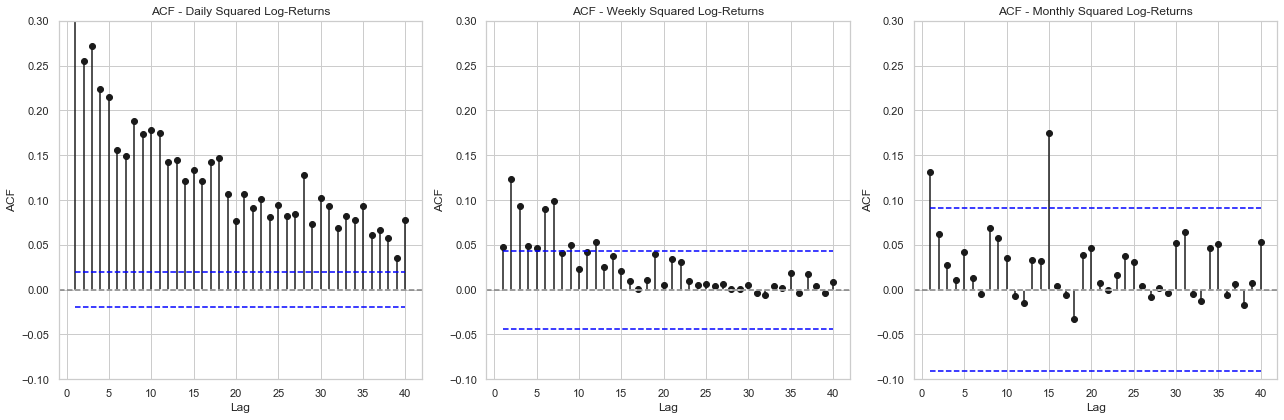

In [1012]:


# Layour set up
lags = 40
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# ACF of Daily Squared Log Returns
acf_values_daily = acf(rt_d_all**2, nlags=lags)

# Bartlet intervals
confint = 1.96 / np.sqrt(len(rt_d_all))
confint_upper = np.full(lags, confint)
confint_lower = -np.full(lags, confint)

axs[0].stem(np.arange(1, lags + 1), acf_values_daily[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].plot(np.arange(1, lags + 1), confint_upper, color='blue', linestyle='dashed')
axs[0].plot(np.arange(1, lags + 1), confint_lower, color='blue', linestyle='dashed')
axs[0].set_ylim(-0.1, 0.3)
axs[0].set_title('ACF - Daily Squared Log-Returns')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('ACF')
axs[0].grid(True)

# ACF of Weekly Squared Log Returns
acf_values_weekly = acf(rt_w_all**2, nlags=lags)
confint_weekly = 1.96 / np.sqrt(len(rt_w_all))
confint_weekly_upper = np.full(lags, confint_weekly)
confint_weekly_lower = -np.full(lags, confint_weekly)

axs[1].stem(np.arange(1, lags + 1), acf_values_weekly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_upper, color='blue', linestyle='dashed')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_lower, color='blue', linestyle='dashed')
axs[1].set_ylim(-0.1, 0.3)
axs[1].set_title('ACF - Weekly Squared Log-Returns')
axs[1].set_xlabel('Lag')
axs[1].set_ylabel('ACF')
axs[1].grid(True)

# ACF of Monthly Squared Log Returns 
acf_values_monthly = acf(rt_m_all**2, nlags=lags)
confint_monthly = 1.96 / np.sqrt(len(rt_m_all))
confint_monthly_upper = np.full(lags, confint_monthly)
confint_monthly_lower = -np.full(lags, confint_monthly)

axs[2].stem(np.arange(1, lags + 1), acf_values_monthly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[2].axhline(y=0, color='gray', linestyle='--')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_upper, color='blue', linestyle='dashed')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_lower, color='blue', linestyle='dashed')
axs[2].set_ylim(-0.1, 0.3)
axs[2].set_title('ACF - Monthly Squared Log-Returns')
axs[2].set_xlabel('Lag')
axs[2].set_ylabel('ACF')
axs[2].grid(True)

plt.tight_layout()
plt.show()



Detailed ACF Table for Squared Returns with Tests

In [1013]:


# Max lag
my_max_lag = 25
lags_all = np.arange(1, my_max_lag + 1)

# Empirical ACF for ^2 returns
my_acf = sm.tsa.acf(rt_d_all**2, nlags=my_max_lag)

# ACF diameter (confidence interval)
my_acf_diameter = 1.96 / np.sqrt(len(rt_d_all))

# ACF t-test statistic
my_acf_tstat_0 = (my_acf[1:] - 0) / np.sqrt(1 / len(rt_d_all))

# Ljung-Box test on ^2 returns
my_LjungBox = sm.stats.diagnostic.acorr_ljungbox(rt_d_all**2, lags=lags_all, boxpierce=False)

# Box-Pierce test on ^2 returns
my_BoxPierce = sm.stats.diagnostic.acorr_ljungbox(rt_d_all**2, lags=lags_all, boxpierce=True)

# Chi-square critical value
crit_value_5_BP = stats.chi2.ppf(0.95, lags_all)

# Table
my_table = np.column_stack((
    lags_all,
    my_acf[1:],
    np.full(my_max_lag, my_acf_diameter),
    my_acf_tstat_0,
    my_BoxPierce['bp_stat'],
    my_BoxPierce['bp_pvalue'],
    my_LjungBox['lb_stat'],
    my_LjungBox['lb_pvalue'],
    crit_value_5_BP
))

column_names = ["lag", "acf", "acf diam.", "acf test", 
                "B-P stat", "B-P pval", "L-B stat", "L-B pval", "crit"]
my_table_df = pd.DataFrame(data=my_table, columns=column_names)

#Rounded table
my_table_df = my_table_df.round(3)
print("Table: ACF of SQUARED Daily Returns with Box-Pierce and Ljung-Box Tests")
print(my_table_df)


Table: ACF of SQUARED Daily Returns with Box-Pierce and Ljung-Box Tests
        lag     acf  acf diam.  acf test   B-P stat  B-P pval   L-B stat  \
0   1.00000 0.34400    0.02000  34.12600 1164.56700   0.00000 1164.92100   
1   2.00000 0.25500    0.02000  25.32700 1806.04100   0.00000 1806.65600   
2   3.00000 0.27200    0.02000  26.98500 2534.23200   0.00000 2535.21700   
3   4.00000 0.22400    0.02000  22.19800 3026.99000   0.00000 3028.27500   
4   5.00000 0.21500    0.02000  21.32100 3481.56500   0.00000 3483.17300   
5   6.00000 0.15600    0.02000  15.48900 3721.47700   0.00000 3723.28100   
6   7.00000 0.14900    0.02000  14.77200 3939.69800   0.00000 3941.70100   
7   8.00000 0.18800    0.02000  18.62700 4286.65400   0.00000 4289.00900   
8   9.00000 0.17400    0.02000  17.24600 4584.08700   0.00000 4586.77600   
9  10.00000 0.17800    0.02000  17.62500 4894.74300   0.00000 4897.81000   
10 11.00000 0.17400    0.02000  17.31000 5194.37200   0.00000 5197.83500   
11 12.00000 0.14

ACF of Absolute Returns (d, w, m)

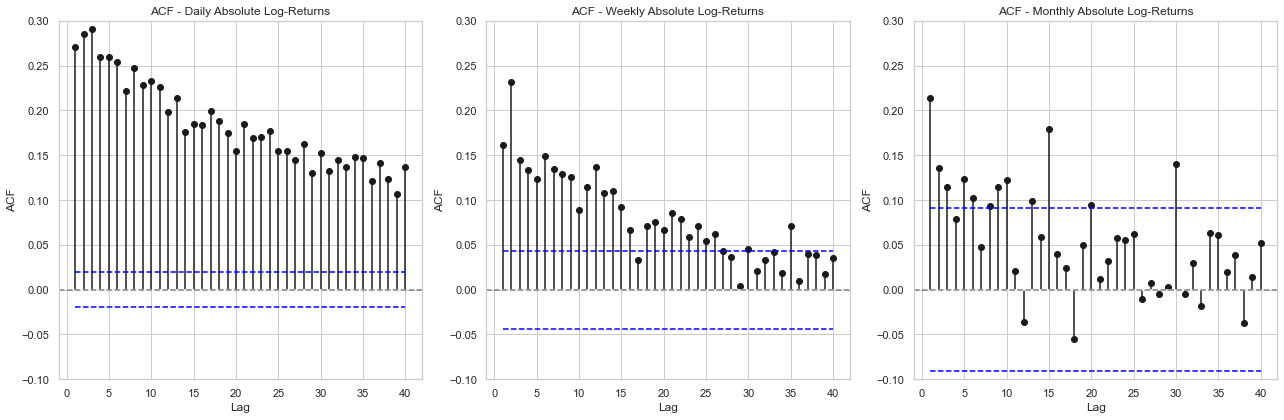

In [1014]:
# Layout set up
lags = 40
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# ACF of Daily Absolute Log Returns 
acf_values_daily = acf(abs(rt_d_all), nlags=lags)
confint = 1.96 / np.sqrt(len(rt_d_all))
confint_upper = np.full(lags, confint)
confint_lower = -np.full(lags, confint)

axs[0].stem(np.arange(1, lags + 1), acf_values_daily[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].plot(np.arange(1, lags + 1), confint_upper, color='blue', linestyle='dashed')
axs[0].plot(np.arange(1, lags + 1), confint_lower, color='blue', linestyle='dashed')
axs[0].set_ylim(-0.1, 0.3)
axs[0].set_title('ACF - Daily Absolute Log-Returns')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('ACF')
axs[0].grid(True)

# ACF of Weekly Absolute Log Returns 
acf_values_weekly = acf(abs(rt_w_all), nlags=lags)
confint_weekly = 1.96 / np.sqrt(len(rt_w_all))
confint_weekly_upper = np.full(lags, confint_weekly)
confint_weekly_lower = -np.full(lags, confint_weekly)

axs[1].stem(np.arange(1, lags + 1), acf_values_weekly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_upper, color='blue', linestyle='dashed')
axs[1].plot(np.arange(1, lags + 1), confint_weekly_lower, color='blue', linestyle='dashed')
axs[1].set_ylim(-0.1, 0.3)
axs[1].set_title('ACF - Weekly Absolute Log-Returns')
axs[1].set_xlabel('Lag')
axs[1].set_ylabel('ACF')
axs[1].grid(True)

# ACF of Monthly Absolute Log-Returns 
acf_values_monthly = acf(abs(rt_m_all), nlags=lags)
confint_monthly = 1.96 / np.sqrt(len(rt_m_all))
confint_monthly_upper = np.full(lags, confint_monthly)
confint_monthly_lower = -np.full(lags, confint_monthly)

axs[2].stem(np.arange(1, lags + 1), acf_values_monthly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[2].axhline(y=0, color='gray', linestyle='--')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_upper, color='blue', linestyle='dashed')
axs[2].plot(np.arange(1, lags + 1), confint_monthly_lower, color='blue', linestyle='dashed')
axs[2].set_ylim(-0.1, 0.3)
axs[2].set_title('ACF - Monthly Absolute Log-Returns')
axs[2].set_xlabel('Lag')
axs[2].set_ylabel('ACF')
axs[2].grid(True)

plt.tight_layout()
plt.show()

Rolling Standard Deviation (252-day window)

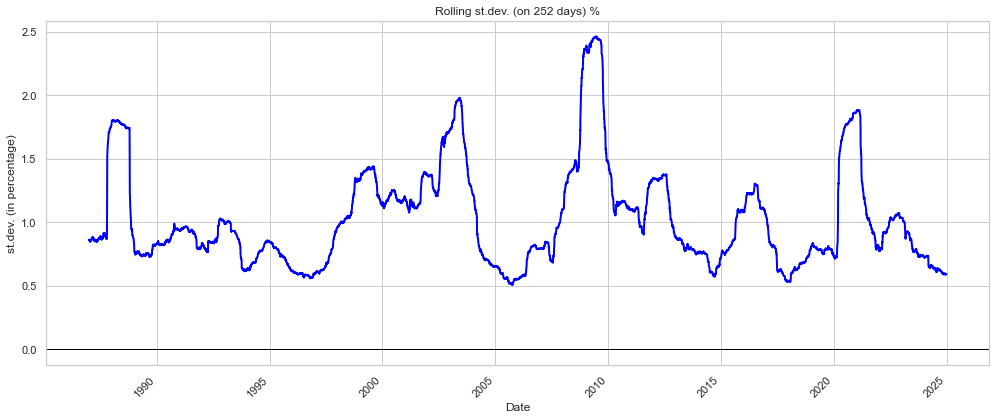

In [1015]:
# Rolling standard deviation (252 trading days = 1 year)
window_length = 252
roll_std = rt_d_all.rolling(window=window_length).std()

# Extraction of the standard deviation
sd_plot = roll_std.squeeze()

# DataFrame
data_index = rt_d_all.index
data2plot_na = pd.DataFrame({'StD': sd_plot}, index=data_index)

# Remove missing values
data2plot = data2plot_na.dropna()

#Plot
plt.figure(figsize=(14, 6))
plt.plot(data2plot.index, data2plot["StD"] * 100, color='blue', linestyle='-', linewidth=2)
plt.xlabel('Date')
plt.grid(True)
plt.ylabel('st.dev. (in percentage)')
plt.title('Rolling st.dev. (on 252 days) %')
plt.axhline(0, linestyle='-', color='black', linewidth=1)

plt.gcf().autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


In [1016]:
#error fix with 1 dimension conversion for pandas:
print(type(sd_plot), sd_plot.shape)
print(len(sd_plot), len(data_index))
data2plot_na = pd.DataFrame({'StD': sd_plot.squeeze()}, index=data_index)

<class 'pandas.core.series.Series'> (9849,)
9849 9849


### Stylized Fact 8

Date Interval definition

In [1017]:
# definition of the interval of dates
ss_start_date3 = pd.to_datetime('1985-12-01')
ss_end_date3 = pd.to_datetime('2024-12-31')


Interval selection and squared returns computation



In [1018]:
# Interval selection
rt_d = rt_d_all.loc[ss_start_date3:ss_end_date3]
# Squared returns computation
rt_d2 = rt_d**2


Price data preparation



In [1019]:
# price data selection
Pt_d = Pt_d_all.loc[ss_start_date3:ss_end_date3]
Pt_d = Pt_d.to_frame() if isinstance(Pt_d, pd.Series) else Pt_d
Pt_d = Pt_d.rename(columns={Pt_d.columns[0]: "Pt.d"})


In [1020]:
# Handle multi-column structure from yfinance
if isinstance(ftse.columns, pd.MultiIndex):
    Pt_d_all = ftse['Close'].iloc[:, 0]  # Get first column
else:
    Pt_d_all = ftse['Close']

# Calculate log returns
rt_d_all = np.log(Pt_d_all / Pt_d_all.shift(1)).dropna()

# Set dates
ss_start_date3 = pd.to_datetime('1985-12-01')
ss_end_date3 = pd.to_datetime('2024-12-31')

# Select interval
rt_d = rt_d_all.loc[ss_start_date3:ss_end_date3]
rt_d2 = rt_d**2

# Get price data - convert Series to DataFrame
Pt_d = pd.DataFrame({'Pt.d': Pt_d_all.loc[ss_start_date3:ss_end_date3]})


print("all good")
print(Pt_d.head())


all good
                 Pt.d
Date                 
1985-12-31 1412.59998
1986-01-02 1420.50000
1986-01-03 1429.80005
1986-01-06 1424.09998
1986-01-07 1415.19995


Plot of the time series: FTSE and rolling volatility

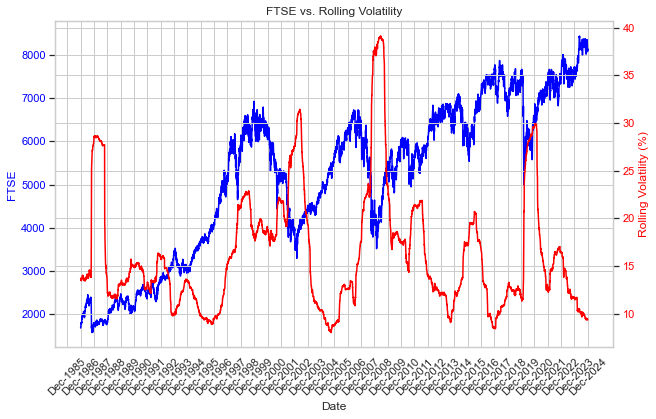

In [1021]:

#EDITS FOR ROLLING VOL

# Multi-column structure handling
if isinstance(ftse.columns, pd.MultiIndex):
    Pt_d_all = ftse['Close'].iloc[:, 0]
else:
    Pt_d_all = ftse['Close']

# log returns
rt_d_all = np.log(Pt_d_all / Pt_d_all.shift(1)).dropna()

# Date setting
ss_start_date3 = pd.to_datetime('1985-12-01')
ss_end_date3 = pd.to_datetime('2024-12-31')

# interval choice
rt_d = rt_d_all.loc[ss_start_date3:ss_end_date3]
Pt_d = Pt_d_all.loc[ss_start_date3:ss_end_date3]

# Annualized rolling volatility (252-day window) 
window_length = 252
rolling_vol = rt_d.rolling(window=window_length).std() * np.sqrt(252) * 100  # Annualized in percentage

# Close prices extraction
Pt_d = Pt_d

# Column renaming
rolling_vol = rolling_vol.rename('Vol.d')
Pt_d = Pt_d.rename('Pt.d')

#END OF EDITS FOR ROLLING VOL

# Merging of the two datasets
merged_df = pd.merge(Pt_d, rolling_vol, on='Date', how='outer')  
# outer: only common indexes (dates)
merged_df.head()

# Computation of the changes in pt and Vol compared to previous period (we keep NaN)
diff_df = merged_df.diff()
diff_df.head()

# Price dataframe removal
merged_df = merged_df.dropna()
# and from the second one
diff_df = diff_df.dropna()

# Plot parameters
fig, ax1 = plt.subplots(figsize=(10, 6))


date_labels = pd.date_range(start='1985-01-01', end='2024-12-31', freq='A-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]

plt.xticks(date_labels, formatted_labels, rotation=45)

ax1.plot(merged_df.index, merged_df['Pt.d'], label='FTSE Prices', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('FTSE', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(merged_df.index, merged_df['Vol.d'], label='Rolling Volatility', color='red')
ax2.set_ylabel('Rolling Volatility (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('FTSE vs. Rolling Volatility')
plt.grid(True)

plt.savefig('FTSE_Vol_1985_2024.png', format='png', bbox_inches='tight')

plt.show()


First differences plot



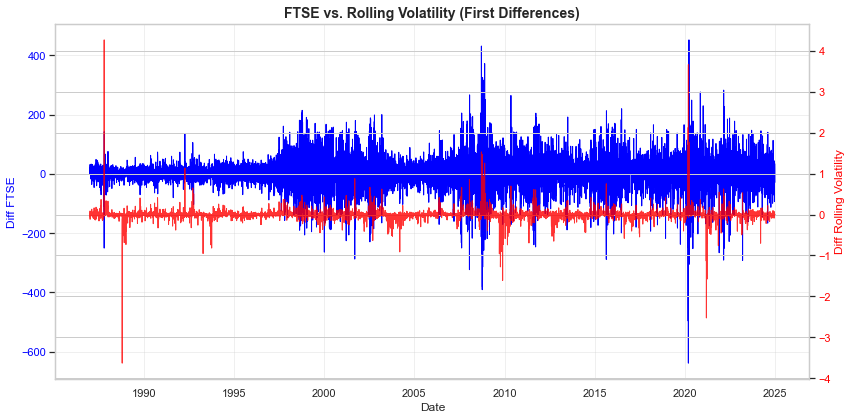

In [1022]:


#START OF EDITS FOR ROLLING VOL

# Calculation of rolling volatility from returns (252-day window)
window_length = 252
rolling_vol = rt_d_all.rolling(window=window_length).std() * np.sqrt(252) * 100  # Annualized %

# Alignement of rolling volatility with the merged_df index
rolling_vol_aligned = rolling_vol.loc[merged_df.index]

# Calculation of first differences for both FTSE prices and rolling volatility
diff_ftse = merged_df['Pt.d'].diff().dropna()
diff_rolling_vol = rolling_vol_aligned.diff().dropna()

# Alignement of both series to have matching indices
common_index = diff_ftse.index.intersection(diff_rolling_vol.index)
diff_ftse = diff_ftse.loc[common_index]
diff_rolling_vol = diff_rolling_vol.loc[common_index]

#Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

#EDITS FOR ROLLING VOL END

ax1.plot(diff_ftse.index, diff_ftse, label='FTSE Price Differences', color='blue', linewidth=1)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Diff FTSE', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(diff_rolling_vol.index, diff_rolling_vol, label='Diff Rolling Volatility', 
         color='red', linewidth=1, alpha=0.8)
ax2.set_ylabel('Diff Rolling Volatility', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('FTSE vs. Rolling Volatility (First Differences)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


Scatter with the regression line

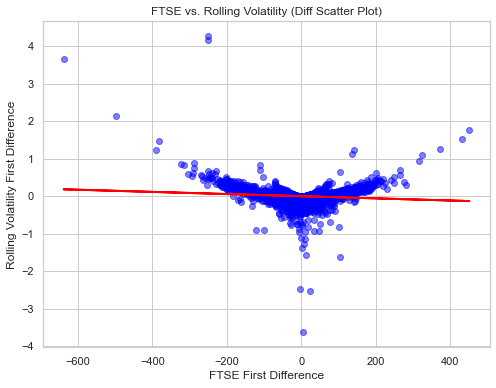

In [1023]:
#WITH ROLLING START

# Rolling volatility from FTSE returns (annualized, 252-day window)
window_length = 252
rolling_vol = rt_d_all.rolling(window=window_length).std() * np.sqrt(252) * 100  # %

# Alignement to merged_df dates
rolling_vol_aligned = rolling_vol.loc[merged_df.index]

# First differences
diff_ftse = merged_df['Pt.d'].diff().dropna()
diff_rolling_vol = rolling_vol_aligned.diff().dropna()

# Alignement of both for same index
common_index = diff_ftse.index.intersection(diff_rolling_vol.index)
x = diff_ftse.loc[common_index]
y = diff_rolling_vol.loc[common_index]

#WITH ROLING VOL END

# Plotting:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.5)
plt.xlabel('FTSE First Difference')
plt.ylabel('Rolling Volatility First Difference')
plt.title('FTSE vs. Rolling Volatility (Diff Scatter Plot)')
plt.grid(True)

# Regression line:
coefficients = np.polyfit(x, y, 1)
reg_line = np.polyval(coefficients, x)
plt.plot(x, reg_line, color='red', linewidth=2)

plt.show()


Leverage Effect: Cross-correlation plot

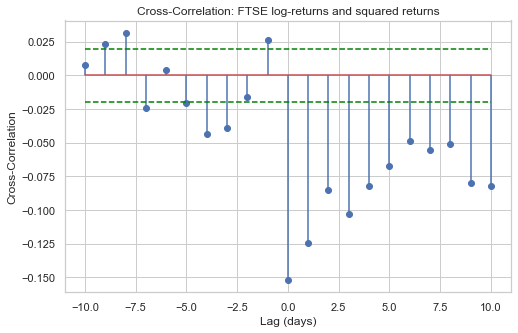

In [1024]:
def ccf(x, y, lag_max=10):
    result = ss.correlate(y - np.mean(y), x - np.mean(x), method='direct') / (np.std(y) * np.std(x) * len(y))
    length = (len(result) - 1) // 2
    lo = length - lag_max
    hi = length + (lag_max + 1)
    return result[lo:hi]

lag_max = 10
cross_corr = ccf(rt_d, rt_d2, lag_max=lag_max)
lags = np.arange(-lag_max, lag_max + 1)
confint_daily = 1.96 / np.sqrt(len(rt_d))
confint_daily_upper = np.full(len(lags), confint_daily)
confint_daily_lower = -np.full(len(lags), confint_daily)

plt.figure(figsize=(8, 5))
plt.stem(lags, cross_corr)
plt.plot(lags, confint_daily_upper, color='green', linestyle='dashed')
plt.plot(lags, confint_daily_lower, color='green', linestyle='dashed')
plt.xlabel('Lag (days)')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation: FTSE log-returns and squared returns')
plt.grid(True)
plt.show()


In [1025]:
#Last check fot the rolling std
# First 10 values of rolling std (not NaNs)
print(sd_plot[:10])

# First 10 valid (non-NaN) values
print(sd_plot[window_length:window_length+10])

# NaN removal
sd_plot_clean = pd.Series(sd_plot, index=data_index).dropna()
print(sd_plot_clean.head())


Date
1986-01-02   NaN
1986-01-03   NaN
1986-01-06   NaN
1986-01-07   NaN
1986-01-08   NaN
1986-01-09   NaN
1986-01-10   NaN
1986-01-13   NaN
1986-01-14   NaN
1986-01-15   NaN
Name: Pt.d, dtype: float64
Date
1986-12-31   0.00860
1987-01-02   0.00859
1987-01-05   0.00859
1987-01-06   0.00858
1987-01-07   0.00864
1987-01-08   0.00857
1987-01-09   0.00857
1987-01-12   0.00855
1987-01-13   0.00853
1987-01-14   0.00848
Name: Pt.d, dtype: float64
Date
1986-12-30   0.00860
1986-12-31   0.00860
1987-01-02   0.00859
1987-01-05   0.00859
1987-01-06   0.00858
Name: Pt.d, dtype: float64


In [1026]:
#Everything seems normal: the reason for initial NANs are insufficient data points for the rolling calculation (like a moving std dev): we need a window of data points before we can output a value


In [1027]:
# === Fama–French 3 Factors (Monthly) → merge con i vostri ritorni mensili ===
# IMPORTANT: This cell assumes the previous cell already defined:
# - FF_raw with columns ['Mkt-RF','SMB','HML','RF']
# - ffm_m = FF_raw[['Mkt-RF','SMB','HML']].rename(columns={'Mkt-RF':'Mkt_RF'})
# - rf_m  = FF_raw[['RF']]

# 3) I VOSTRI ritorni mensili (log-returns) → percentuale e indice a fine mese
rt_m_local = rt_m_all.copy()
rt_m_local.index = rt_m_local.index + pd.offsets.MonthEnd(0)
rt_m_pct = rt_m_local.to_frame(name="Asset") * 100

# 4) Merge (inner) su date comuni
data_m = rt_m_pct.join(ffm_m, how="inner").join(rf_m, how="inner")

# --- OUTPUT & DIAGNOSTICA (mostra sempre qualcosa) ---
print("rt_m_all:", rt_m_local.index.min().date(), "→", rt_m_local.index.max().date(), "| n =", len(rt_m_local))
print("FF 3F   :", ffm_m.index.min().date(),      "→", ffm_m.index.max().date(),      "| n =", len(ffm_m))
print("MERGE   :", data_m.shape)

print("\nHEAD:")
display(data_m.head())
print("\nTAIL:")
display(data_m.tail())

# Se l'inner è vuoto, faccio un LEFT join per capire dove manca l'incrocio
if data_m.empty:
    print("\nATTENZIONE: Inner join vuoto. Diagnostica con LEFT join:")
    data_left = rt_m_pct.join(ffm_m, how="left").join(rf_m, how="left")
    print("LEFT MERGE shape:", data_left.shape,
          "| righe con fattori NA:", data_left[["Mkt_RF","SMB","HML","RF"]].isna().all(axis=1).sum())
    print("\nPrime righe con NA nei fattori:")
    display(data_left[data_left[["Mkt_RF","SMB","HML","RF"]].isna().any(axis=1)].head(10))


rt_m_all: 1986-01-31 → 2024-12-31 | n = 468
FF 3F   : 1926-07-31 → 2025-08-31 | n = 697
MERGE   : (293, 5)

HEAD:


,Asset,Mkt_RF,SMB,HML,RF
Date,,,,,
1986-01-31,0.21668,0.65000,1.15000,0.46000,NaN
1986-02-28,1.00127,7.14000,-0.57000,-0.63000,NaN
1986-03-31,1.05398,4.91000,-0.54000,-0.39000,NaN
1986-05-31,-0.47811,4.62000,-1.36000,-0.14000,NaN
1986-06-30,0.39089,1.06000,-0.93000,1.20000,NaN



TAIL:


,Asset,Mkt_RF,SMB,HML,RF
Date,,,,,
2024-06-30,-0.15022,2.80000,-3.00000,-3.36000,NaN
2024-07-31,0.27349,1.22000,6.81000,5.62000,NaN
2024-08-31,0.01137,1.60000,-3.49000,-1.10000,NaN
2024-09-30,-0.18622,1.72000,-0.13000,-2.77000,NaN
2024-11-30,0.23984,6.49000,4.46000,0.15000,NaN


In [1028]:
# === Excess return + DataFrame pronto per regressione (naming coerente con data_m) ===

# 1) Excess return dell'asset (in % mensili, coerente con i FF)
data_m = data_m.copy()
data_m["Exc_Ret_Asset"] = data_m["Asset"] - data_m["RF"]

# 2) DataFrame per regressione Fama–French: y = Excess, X = fattori
#    (se preferisci puoi rinominare 'Exc_Ret_Asset' in 'y' con .rename)
z_m_all = data_m[["Exc_Ret_Asset", "Mkt_RF", "SMB", "HML"]].copy()

# 3) Output rapido per verifica
print("DataFrame pronto per la Regressione Fama–French (z_m_all):", z_m_all.shape)
print("\nHEAD:")
display(z_m_all.head())
print("\nTAIL:")
display(z_m_all.tail())

DataFrame pronto per la Regressione Fama–French (z_m_all): (293, 4)

HEAD:


,Exc_Ret_Asset,Mkt_RF,SMB,HML
Date,,,,
1986-01-31,NaN,0.65000,1.15000,0.46000
1986-02-28,NaN,7.14000,-0.57000,-0.63000
1986-03-31,NaN,4.91000,-0.54000,-0.39000
1986-05-31,NaN,4.62000,-1.36000,-0.14000
1986-06-30,NaN,1.06000,-0.93000,1.20000



TAIL:


,Exc_Ret_Asset,Mkt_RF,SMB,HML
Date,,,,
2024-06-30,NaN,2.80000,-3.00000,-3.36000
2024-07-31,NaN,1.22000,6.81000,5.62000
2024-08-31,NaN,1.60000,-3.49000,-1.10000
2024-09-30,NaN,1.72000,-0.13000,-2.77000
2024-11-30,NaN,6.49000,4.46000,0.15000


In [1029]:
# === Filtro periodo + DataFrame export-friendly (coerente con i vostri nomi) ===
import pandas as pd

# 1) Intervallo di date (inclusivo). Puoi cambiare a piacere.
start_date = "2014-01"
end_date   = "2024-12"

# 2) Safety: assicuriamo che l'indice sia datetime
data_m = data_m.copy()
data_m.index = pd.to_datetime(data_m.index)
z_m_all = z_m_all.copy()
z_m_all.index = pd.to_datetime(z_m_all.index)

# 3) Slicing per periodo
rt_m = data_m.loc[start_date:end_date, ["Mkt_RF", "SMB", "HML", "Asset", "RF"]]
z_m  = z_m_all.loc[start_date:end_date, ["Mkt_RF", "SMB", "HML", "Exc_Ret_Asset"]]

# 4) Alias per il nome dell'asset (se rt_m_all ha un name lo uso, altrimenti 'Asset')
asset_label = rt_m_all.name if isinstance(rt_m_all.name, str) and len(rt_m_all.name) else "Asset"

# 5) DataFrame “piatti” con colonna date; intestazioni come nello screenshot
rt_m_df = pd.DataFrame({
    "date":   rt_m.index,
    "Mkt-RF": rt_m["Mkt_RF"],   # rinomino da underscore a trattino solo per l'export
    "SMB":    rt_m["SMB"],
    "HML":    rt_m["HML"],
    asset_label: rt_m["Asset"],  # es. 'FTSEMIB.MI' se quello è il name
    "rf":     rt_m["RF"]
})

z_m_df = pd.DataFrame({
    "date":           z_m.index,
    "Mkt-RF":         z_m["Mkt_RF"],
    "SMB":            z_m["SMB"],
    "HML":            z_m["HML"],
    "Exc_Ret_FTSE":   z_m["Exc_Ret_Asset"]  # etichetta come nello screenshot
})

# 6) Check veloce
print("rt_m_df shape:", rt_m_df.shape)
print("z_m_df  shape:", z_m_df.shape)
print("\nrt_m_df HEAD:")
display(rt_m_df.head())
print("\nz_m_df HEAD:")
display(z_m_df.head())
print("\nrt_m_df TAIL:")
display(rt_m_df.tail())
print("\nz_m_df TAIL:")
display(z_m_df.tail())

rt_m_df shape: (86, 6)
z_m_df  shape: (86, 5)

rt_m_df HEAD:


,date,Mkt-RF,SMB,HML,monthlogret,rf
Date,,,,,,
2014-02-28,2014-02-28,4.66000,0.36000,-0.35000,0.51055,NaN
2014-03-31,2014-03-31,0.43000,-1.86000,4.90000,-0.35777,NaN
2014-05-31,2014-05-31,2.05000,-1.85000,-0.10000,0.10727,NaN
2014-06-30,2014-06-30,2.60000,3.05000,-0.71000,-0.16781,NaN
2014-08-31,2014-08-31,4.24000,0.41000,-0.57000,0.15010,NaN



z_m_df HEAD:


,date,Mkt-RF,SMB,HML,Exc_Ret_FTSE
Date,,,,,
2014-02-28,2014-02-28,4.66000,0.36000,-0.35000,NaN
2014-03-31,2014-03-31,0.43000,-1.86000,4.90000,NaN
2014-05-31,2014-05-31,2.05000,-1.85000,-0.10000,NaN
2014-06-30,2014-06-30,2.60000,3.05000,-0.71000,NaN
2014-08-31,2014-08-31,4.24000,0.41000,-0.57000,NaN



rt_m_df TAIL:


,date,Mkt-RF,SMB,HML,monthlogret,rf
Date,,,,,,
2024-06-30,2024-06-30,2.80000,-3.00000,-3.36000,-0.15022,NaN
2024-07-31,2024-07-31,1.22000,6.81000,5.62000,0.27349,NaN
2024-08-31,2024-08-31,1.60000,-3.49000,-1.10000,0.01137,NaN
2024-09-30,2024-09-30,1.72000,-0.13000,-2.77000,-0.18622,NaN
2024-11-30,2024-11-30,6.49000,4.46000,0.15000,0.23984,NaN



z_m_df TAIL:


,date,Mkt-RF,SMB,HML,Exc_Ret_FTSE
Date,,,,,
2024-06-30,2024-06-30,2.80000,-3.00000,-3.36000,NaN
2024-07-31,2024-07-31,1.22000,6.81000,5.62000,NaN
2024-08-31,2024-08-31,1.60000,-3.49000,-1.10000,NaN
2024-09-30,2024-09-30,1.72000,-0.13000,-2.77000,NaN
2024-11-30,2024-11-30,6.49000,4.46000,0.15000,NaN


In [1035]:
rt_m_df = pd.DataFrame({
    "date": rt_m.index,
    "Mkt-RF": rt_m["Mkt_RF"],
    "SMB": rt_m["SMB"],
    "HML": rt_m["HML"],
    asset_label: rt_m["Asset"],
    "rf": rt_m["RF"]   # <-- was rt_m["rf"]
})


In [1036]:
# Repair/construct risk-free 'rf' in rt_m_df from the merged factors
rt_m_df = rt_m_df.copy()
rt_m_df["date"] = pd.to_datetime(rt_m_df["date"])

# Start from existing 'rf' if present, coerce to numeric
if "rf" in rt_m_df.columns:
    rt_m_df["rf"] = pd.to_numeric(rt_m_df["rf"], errors="coerce")
else:
    rt_m_df["rf"] = np.nan

# If empty, pull from data_m['RF'] on matching dates
if rt_m_df["rf"].notna().sum() == 0:
    # data_m is your inner-joined frame with 'RF' on a DatetimeIndex (month-end)
    if "RF" in data_m.columns:
        rf_aligned = data_m["RF"].reindex(rt_m_df["date"]).to_numpy()
        rt_m_df["rf"] = rf_aligned

# Ensure numeric and in percent units
rt_m_df["rf"] = pd.to_numeric(rt_m_df["rf"], errors="coerce")
if rt_m_df["rf"].abs().max(skipna=True) < 0.05:  # likely in decimals → convert to %
    rt_m_df["rf"] = rt_m_df["rf"] * 100

# Quick sanity check
print("rf_non_na:", int(rt_m_df["rf"].notna().sum()), " | head:", rt_m_df["rf"].head().to_list())


rf_non_na: 0  | head: [nan, nan, nan, nan, nan]


In [1045]:
# Build the plotting frame strictly from the inner join
# Assumes data_m columns: ['Asset','Mkt_RF','SMB','HML','RF'] with a DatetimeIndex at month-end

start_date = "2014-01-31"   # use the same dates as your friend
end_date   = "2024-11-30"

dm = data_m.loc[start_date:end_date].copy()

# Units: Asset should already be % if you multiplied earlier; RF from FF is in %, keep as-is.
# If your RF ended up in decimals, uncomment the next two lines:
# if dm["RF"].abs().max(skipna=True) < 0.05:
#     dm["RF"] = dm["RF"] * 100

plot_df = pd.DataFrame({
    "date": dm.index,
    "monthlogret": dm["Asset"],   # use the same asset column name your friend plots
    "rf": dm["RF"],               # pull RF directly from data_m
    "Mkt-RF": dm["Mkt_RF"],
    "SMB": dm["SMB"],
    "HML": dm["HML"]
})
plot_df["date"] = pd.to_datetime(plot_df["date"])

# Quick diagnostics to confirm parity
print({
    "date_min": plot_df["date"].min(),
    "date_max": plot_df["date"].max(),
    "rows": len(plot_df),
    "asset_non_na": int(pd.to_numeric(plot_df["monthlogret"], errors="coerce").notna().sum()),
    "rf_non_na": int(pd.to_numeric(plot_df["rf"], errors="coerce").notna().sum()),
})
print("2020 rows:", int(((plot_df["date"] >= "2020-01-01") & (plot_df["date"] <= "2020-12-31")).sum()))


{'date_min': Timestamp('2014-02-28 00:00:00'), 'date_max': Timestamp('2024-11-30 00:00:00'), 'rows': 86, 'asset_non_na': 86, 'rf_non_na': 0}
2020 rows: 5


{'asset_non_na': 86, 'rf_non_na': 0}


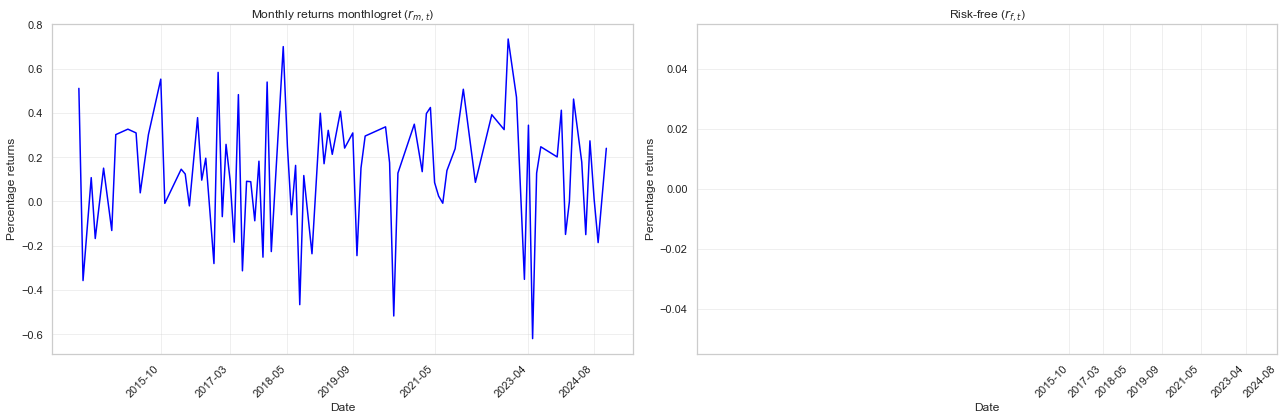

In [1046]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d2plot = plot_df.copy()
d2plot["date"] = pd.to_datetime(d2plot["date"])

y_asset = pd.to_numeric(d2plot["monthlogret"], errors="coerce")
y_rf    = pd.to_numeric(d2plot["rf"], errors="coerce")

mask_asset = y_asset.notna()
mask_rf    = y_rf.notna()

# Ticks every 12 months by position
seq = np.arange(11, len(d2plot), 12)
date_lab = d2plot["date"].iloc[seq]

print({"asset_non_na": int(mask_asset.sum()), "rf_non_na": int(mask_rf.sum())})

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Left: Asset (%)
axs[0].plot(d2plot.loc[mask_asset, "date"], y_asset.loc[mask_asset],
            linestyle='-', marker='', color='blue')
axs[0].set_xlabel('Date'); axs[0].set_ylabel('Percentage returns')
axs[0].set_title('Monthly returns monthlogret ($r_{m,t}$)')
axs[0].set_xticks(date_lab); axs[0].set_xticklabels(date_lab.dt.strftime('%Y-%m'), rotation=45, ha="right")
axs[0].grid(True, alpha=0.3)

# Right: Risk-free (%)
axs[1].plot(d2plot.loc[mask_rf, "date"], y_rf.loc[mask_rf],
            linestyle='-', marker='', color='green')
axs[1].set_xlabel('Date'); axs[1].set_ylabel('Percentage returns')
axs[1].set_title('Risk-free ($r_{f,t}$)')
axs[1].set_xticks(date_lab); axs[1].set_xticklabels(date_lab.dt.strftime('%Y-%m'), rotation=45, ha="right")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [1047]:
print("Sample from 2020:")
print(dm.loc["2020-01-31":"2020-12-31", ["Asset","RF"]].head(12))
print("Any RF NaNs in dm:", dm["RF"].isna().sum())


Sample from 2020:
              Asset  RF
Date                   
2020-05-31  0.33676 NaN
2020-06-30  0.17437 NaN
2020-07-31 -0.51777 NaN
2020-08-31  0.12771 NaN
2020-12-31  0.34866 NaN
Any RF NaNs in dm: 86
